# E80 · A gravitational lens, pixel by pixel

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: a **Hubble Space Telescope** image of the Einstein ring **SDSS J1627-0053** (ACS/WFC, F814W filter, 2,224 s in four exposures, 2006; HST programme 10494; the pipeline's drizzled, CTE-corrected image from **MAST**): a 6" cutout of the lens with its exposure-time map, an empty patch of sky for the noise, and nine stars from the same image for the point-spread function. Redshifts and published lens models from the **Sloan Lens ACS Survey** (Bolton et al. 2008; Koopmans et al. 2006) |
| **You will learn** | The **lens equation** and ray tracing from the image plane back to the source plane · the deflection of a **singular isothermal ellipsoid** plus external shear in closed form, tested with automatic differentiation (divergence = twice the convergence, zero curl) · **critical curves and caustics** · a likelihood for **every pixel** of an image: a noise map from photon counts, **correlated noise** from drizzling handled by whitening in Fourier space, **PSF convolution** by FFT, the lens galaxy's own light fitted at the same time · **linear parameters integrated out** analytically · multi-start optimisation and **wrong modes** · failures: no PSF, independent-pixel noise · NUTS in PyMC on a JAX likelihood with a **low-rank mass matrix** · a **pixelated source** with a Gaussian regularising prior, marginalised exactly, and the **Bayesian evidence** for the regularisation strength and form (Suyu et al. 2006) · the **mass-sheet degeneracy**: an exact symmetry of the image, and what breaks it · from an angle to a mass: **angular-diameter distances** and the critical density · uncertainty displays: residual panels, a source reconstruction with its spread, critical-curve and caustic spaghetti, a hypothetical-outcome animation of the unlensed galaxy |

## The setting

Mass bends light. A galaxy sitting almost exactly in front of a more distant one acts as a lens:
light from the background galaxy reaches us along several paths around the foreground one, and if
the alignment is close enough the background galaxy is smeared into a ring, an **Einstein ring**.
Einstein (1936) thought such rings would never be seen. The **Sloan Lens ACS Survey** (SLACS) found
about seventy of them: it searched the spectra of a million galaxies in the Sloan Digital Sky Survey
for emission lines at a second, higher redshift - a background galaxy hiding in the same fibre - and
imaged the candidates with the Hubble Space Telescope.

**SDSS J1627-0053** is one of the cleanest. The lens is a massive elliptical galaxy at redshift
$z_l = 0.2076$ (light travel time about 2.5 billion years); the ring is a star-forming galaxy at
$z_s = 0.5241$ behind it (5.2 billion years). The ring's radius measures the mass of the lens galaxy
inside it - dark matter included - without any assumption about its stars.

The usual way to "measure" a lens is to reduce the image to a few numbers (positions of bright spots,
a radius) and fit those. Here we do what professional lens modellers do: **predict every pixel of
the image** - the lens galaxy's light, the lensed background galaxy, blurred by the telescope,
with the right noise - and let the posterior over the lens's mass *and* the background galaxy's
shape follow from all 6,561 pixels at once. The questions:

1. How much mass is inside the ring, and how sure are we?
2. What does the background galaxy look like *unlensed*?
3. What can an image **not** tell us, however good it is?

| part | question | tool |
|---|---|---|
| A | What is in the image? | exposure-time map, photon noise, correlated noise from drizzling, a PSF from stars |
| B | How does a lens bend light? | the lens equation, an isothermal ellipsoid with shear, autodiff unit tests, critical curves and caustics, a prior predictive check |
| C | Can we predict every pixel? | a forward model with the lens galaxy's light, linear amplitudes integrated out, multi-start optimisation, two failures (no PSF, independent noise), NUTS in PyMC |
| D | What does the background galaxy look like? | a pixelated source with a Gaussian prior solved exactly, the evidence for the regularisation, a lens refit, the source with its uncertainty, an animation |
| E | What can the image not tell us? | the mass-sheet degeneracy, demonstrated exactly; what breaks it |
| F | How much mass is in the ring? | angular-diameter distances, the critical density, comparison with published models, caustic spaghetti |

Everything uses NumPy, SciPy, JAX and PyMC - no astronomy packages. The HST image was cut out of the
215 MB pipeline product once by `tools/build_e80_lens.py`.

In [1]:
import io
import logging
import time
import warnings

import arviz as az
import contourpy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from IPython.display import HTML, Image, display
from matplotlib import animation
from pytensor import wrap_jax
from scipy import integrate, ndimage, optimize

from pymc_challenges import data

jax.config.update("jax_enable_x64", True)
RANDOM_SEED = 80
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*object mode.*")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)
T_START = time.time()


def show_jpeg(fig, quality=85):
    """Images of the sky compress badly as PNG: show them as JPEG."""
    buf = io.BytesIO()
    fig.savefig(buf, format="jpeg", dpi=90, pil_kwargs={"quality": quality})
    plt.close(fig)
    display(Image(buf.getvalue()))

## A. The image

The Advanced Camera for Surveys took four 556-second exposures through the F814W filter (a broad
band around 800 nm, near-infrared). The pipeline removed cosmic rays, corrected the camera's
geometric distortion and the charge-transfer losses of the ageing detector, subtracted the sky, and
combined the exposures onto a 0.05" grid ("drizzling"). The units are **electrons per second**. The
weight map records, for every output pixel, how many seconds of exposure went into it.

The build script turned the cutouts by a multiple of 90 degrees so that north is up and east is
left (to within the small angle printed below).

slacs_j1627: NumPy .npz (open data.path(...) with np.load), all arrays turned by a multiple of 90 degrees so that north is up and east left (north_residual_deg: the remaining angle of north from +y, towards -x): sci (121 x 121 cutout centred on the lens galaxy, electrons/s, sky subtracted by the pipeline), wht (the same, effective exposure time in s), blank_sci / blank_wht (128 x 128 empty sky nearby), star_stamps (10 x 41 x 41 isolated stars within 70" of the lens, for the PSF) and star_xy (their positions in the original frame), pixel_scale (0.05 arcsec), exptime, photflam, photplam, ra_dec, lens_xy_full, date_obs, proposal, rootname, filter.
  source: NASA/ESA Hubble Space Telescope, ACS/WFC F814W, programme 10494 (PI L. Koopmans; SLACS follow-up), observed 2006-03-12, 4 exposures, 2,224 s; pipeline-drizzled, CTE-corrected product j9c701020_drc.fits from the Mikulski Archive for Space Telescopes (MAST, STScI). HST archival data are public; MAST asks for the acknowledgement 'Based on

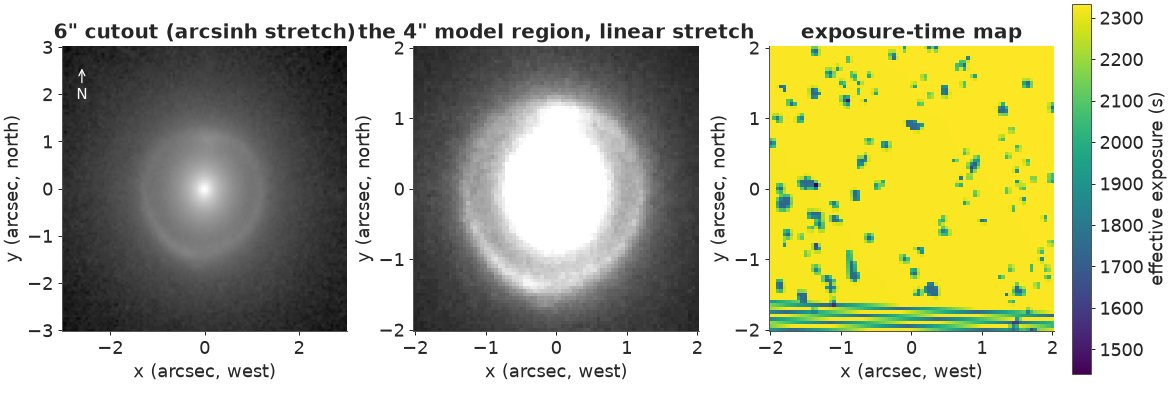

In [2]:
data.describe("slacs_j1627")
raw = np.load(data.path("slacs_j1627"))
PIX = float(raw["pixel_scale"])
NORTH = float(raw["north_residual_deg"])
print(f"{raw['filter']}, {float(raw['exptime']):.0f} s, observed {raw['date_obs']}, programme {raw['proposal']}; "
      f"pixel {PIX:.3f}\"; north is {NORTH:+.1f} deg from the +y axis")
N, SUB = 81, 2                       # 81 x 81 pixels (4.05"), rays traced on a 2 x 2 sub-grid
c, h = 60, N // 2
sci = raw["sci"][c - h:c + h + 1, c - h:c + h + 1].astype(float)
wht = raw["wht"][c - h:c + h + 1, c - h:c + h + 1].astype(float)
EXT = [-(N / 2) * PIX, (N / 2) * PIX] * 2          # image extent in arcsec, lens galaxy at (0, 0)
print(f"cutout {N} x {N}; brightest pixel {sci.max():.1f} e-/s; exposure map {wht.min():.0f}-{wht.max():.0f} s")

fig, axs = plt.subplots(1, 3, figsize=(13, 4.4))
axs[0].imshow(np.arcsinh(raw["sci"] / 0.02), origin="lower", cmap="gray",
              extent=[-3.025, 3.025, -3.025, 3.025])
axs[0].set_title("6\" cutout (arcsinh stretch)")
axs[1].imshow(sci, origin="lower", cmap="gray", vmin=-0.02, vmax=0.5, extent=EXT)
axs[1].set_title("the 4\" model region, linear stretch")
im = axs[2].imshow(wht, origin="lower", cmap="viridis", extent=EXT)
fig.colorbar(im, ax=axs[2], label="effective exposure (s)")
axs[2].set_title("exposure-time map")
for ax in axs:
    ax.set(xlabel="x (arcsec, west)", ylabel="y (arcsec, north)")
axs[0].annotate("N", xy=(-2.6, 2.6), xytext=(-2.6, 1.9), color="w", ha="center",
                arrowprops=dict(arrowstyle="->", color="w"))
show_jpeg(fig)

The ring is obvious in the arcsinh stretch: radius about 1.2", brighter to the north and to the
south-east. It sits on top of the lens galaxy, whose light dominates every pixel inside the ring and
much of the ring itself. The exposure map is nearly flat (about 2,330 s, a little above the 2,224 s total:
the weights are exposure times scaled by how much of each distortion-corrected input pixel overlaps
the output pixel), with small dips where one exposure's pixel was rejected - cosmic rays
or bad pixels - and a striped band along the bottom edge, most likely where some of the dithered
exposures fell into the gap between the camera's two CCDs. The noise model below uses this map
pixel by pixel.

### The noise in every pixel

A pixel's value is a count of electrons divided by the exposure time $t$. Two sources of noise:

* **the sky and the detector**: background photons plus read noise, the same everywhere. We measure
  its standard deviation $\sigma_\text{sky}$ in an empty patch of sky from the same image (after
  masking the few faint objects in it);
* **the photons from the galaxies themselves**: Poisson, so the variance of the count is the count,
  and the variance of the rate is $d/t$.

$$\sigma_i^2 = \sigma_\text{sky}^2 + \frac{\max(\tilde d_i, 0)}{t_i},$$

with $\tilde d$ the image smoothed over 3 x 3 pixels (so the noise map does not follow the noise).

Drizzling adds a complication. Each output pixel is a weighted average of the input pixels that
overlap it, so **neighbouring pixels share noise**. We measure the correlation in the blank patch.

In [3]:
blank = raw["blank_sci"].astype(float)
bres = blank - ndimage.median_filter(blank, 25)               # remove any smooth background
s0 = 1.4826 * np.median(np.abs(bres))
bmask = ndimage.binary_dilation(np.abs(ndimage.uniform_filter(bres, 3)) > 1.5 * s0, iterations=3)
SKY_SD = bres[~bmask].std()
r0, w0 = np.where(bmask, 0, bres), (~bmask).astype(float)
F2, IF2 = np.fft.fft2, np.fft.ifft2
acf = np.real(IF2(np.abs(F2(r0, s=(256, 256)))**2)) / np.maximum(np.real(IF2(np.abs(F2(w0, s=(256, 256)))**2)), 1)
acf = np.fft.fftshift(acf / acf[0, 0])[127:130, 127:130]
acf = (acf + acf[::-1, ::-1]) / 2                             # the correlation is symmetric
print(f"blank patch: {bmask.mean():.1%} masked, sky sd = {SKY_SD:.4f} e-/s per pixel")
print("correlation with the neighbours (3 x 3 lags):\n", np.round(acf, 3))
print(f"sum of correlations: {acf.sum():.2f} - the variance of a sum of many pixels is this many times "
      "what independent pixels would give")

sig = np.sqrt(SKY_SD**2 + np.clip(ndimage.uniform_filter(sci, 3), 0, None) / wht)
print(f"noise map: {sig.min():.4f} e-/s in the cutout's corners (sky + the galaxy's faint halo) to "
      f"{sig.max():.3f} e-/s at the galaxy's centre; the sky term alone is {SKY_SD:.4f}")

blank patch: 4.6% masked, sky sd = 0.0059 e-/s per pixel
correlation with the neighbours (3 x 3 lags):
 [[0.055 0.238 0.056]
 [0.221 1.    0.221]
 [0.056 0.238 0.055]]
sum of correlations: 2.14 - the variance of a sum of many pixels is this many times what independent pixels would give
noise map: 0.0075 e-/s in the cutout's corners (sky + the galaxy's faint halo) to 0.064 e-/s at the galaxy's centre; the sky term alone is 0.0059


Adjacent pixels are correlated by about 0.2 horizontally and vertically and about 0.05 diagonally;
beyond one pixel the correlation is zero within the noise. The sum over all lags, about 2.1, is the
factor by which a likelihood that treats pixels as independent **overstates the information** about
anything that depends on sums over many pixels - which is everything we want. We will see the
consequence in Part C.

The fix is to **whiten** the residuals. If the correlation is stationary with power spectrum $P(k)$
(the Fourier transform of the 3 x 3 kernel above), then dividing the Fourier transform of the
normalised residual image $r/\sigma$ by $\sqrt{P(k)}$ gives independent unit-variance residuals.
The kernel's power spectrum must be positive everywhere for this to work:

In [4]:
KER = np.zeros((N, N))
for dy in (-1, 0, 1):
    for dx in (-1, 0, 1):
        KER[dy % N, dx % N] = acf[dy + 1, dx + 1]
PSPEC = np.real(np.fft.fft2(KER))
print(f"power spectrum of the noise correlation: min {PSPEC.min():.2f}, max {PSPEC.max():.2f} (all > 0)")


def whiten_np(r):
    """Whitened version of a normalised residual image (periodic boundaries)."""
    return np.real(np.fft.ifft2(np.fft.fft2(r) / np.sqrt(PSPEC)))


# check on the blank patch: whitened sky noise should be uncorrelated
bw = whiten_np(np.where(bmask, 0, bres)[:N, :N] / SKY_SD)
lag1 = np.mean(bw[:, 1:] * bw[:, :-1]) / np.mean(bw**2)
print(f"blank sky after whitening: sd {bw[~bmask[:N, :N]].std():.2f}, lag-1 correlation {lag1:+.3f}")

power spectrum of the noise correlation: min 0.30, max 2.14 (all > 0)
blank sky after whitening: sd 0.99, lag-1 correlation -0.003


After whitening, the blank sky is uncorrelated with unit variance (the masked objects bias it
slightly). The periodic boundary of the FFT is an approximation at the edges of the cutout.

### The point-spread function

A telescope blurs every point of light into a small pattern, the **point-spread function** (PSF).
Stars are points, so a star's image *is* the PSF. The build script picked the ten isolated compact
sources nearest the lens (all within 70"); we look at them, drop any that are saturated, recentre the
rest to a common centre by a sub-pixel Fourier shift, normalise each to unit flux and take the median.

peak pixel of each star, electrons per exposure: [80300 25900  8900 15300 27300 16400 26800 33900 38000 14500]
9 stars used; PSF peak 0.147 of the flux; enclosed flux within 1, 2, 4, 8 pixels: 0.43, 0.65, 0.88, 0.95
each star's total |difference| from the median PSF (fraction of flux): [0.042 0.045 0.054 0.064 0.034 0.052 0.054 0.053 0.072]


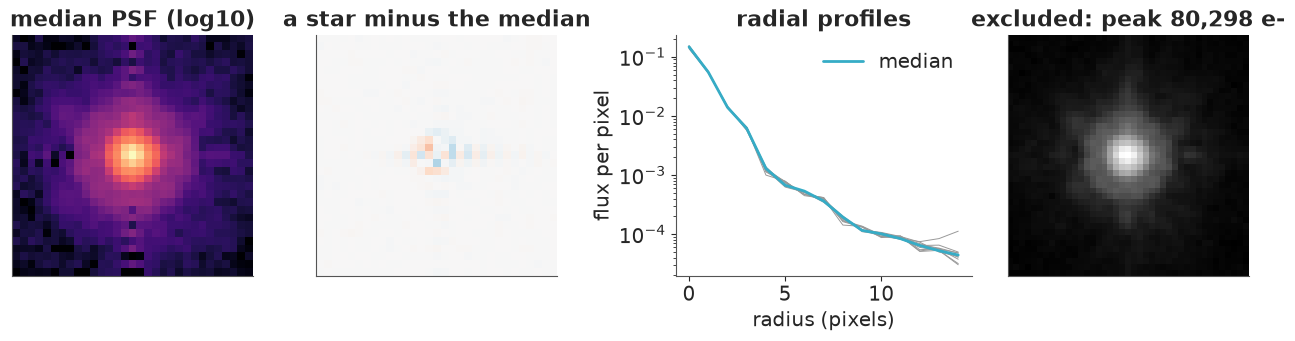

In [5]:
stars = raw["star_stamps"].astype(float)
peak_e = stars.max(axis=(1, 2)) * float(raw["exptime"]) / 4
print("peak pixel of each star, electrons per exposure:", np.round(peak_e, -2).astype(int))


def recentre(st, half=15):
    yy, xx = np.indices(st.shape) - st.shape[0] // 2
    w = np.clip(st, 0, None) * (np.hypot(xx, yy) < 4)
    cx, cy = (w * xx).sum() / w.sum(), (w * yy).sum() / w.sum()
    sh = np.real(np.fft.ifft2(ndimage.fourier_shift(np.fft.fft2(st), (-cy, -cx))))
    m = st.shape[0] // 2
    sh = sh[m - half:m + half + 1, m - half:m + half + 1]
    return sh / sh.sum()


keep_star = peak_e < 60000                     # the WFC full well is about 80,000 electrons
stack = np.array([recentre(s) for s in stars[keep_star]])
PSF = np.clip(np.median(stack, axis=0), 0, None)
PSF /= PSF.sum()
rr = np.hypot(*(np.indices(PSF.shape) - 15))
ee = [PSF[rr <= r].sum() for r in (1, 2, 4, 8)]
print(f"{keep_star.sum()} stars used; PSF peak {PSF.max():.3f} of the flux; enclosed flux within 1, 2, 4, 8 pixels: "
      + ", ".join(f"{e:.2f}" for e in ee))
dev = np.abs(stack - PSF).sum(axis=(1, 2)) / 2
print("each star's total |difference| from the median PSF (fraction of flux):", np.round(dev, 3))

fig, axs = plt.subplots(1, 4, figsize=(13, 3.3))
axs[0].imshow(np.log10(np.clip(PSF, 1e-5, None)), origin="lower", cmap="magma", vmin=-5, vmax=-0.8)
axs[0].set_title("median PSF (log10)")
axs[1].imshow(stack[1] - PSF, origin="lower", cmap="RdBu_r", vmin=-0.01, vmax=0.01)
axs[1].set_title("a star minus the median")
prof = [PSF[(rr >= r - 0.5) & (rr < r + 0.5)].mean() for r in range(15)]
for s in stack:
    axs[2].semilogy(range(15), [s[(rr >= r - 0.5) & (rr < r + 0.5)].mean() for r in range(15)],
                    color="0.6", lw=0.7)
axs[2].semilogy(range(15), prof, color="C0", lw=2, label="median")
axs[2].set(xlabel="radius (pixels)", ylabel="flux per pixel", title="radial profiles")
axs[2].legend()
axs[3].imshow(np.arcsinh(stars[0] / 0.1), origin="lower", cmap="gray")
axs[3].set_title(f"excluded: peak {peak_e[0]:,.0f} e-")
for ax in axs[[0, 1, 3]]:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

The brightest star's peak pixel collected nearly as many electrons as a pixel can hold, so its core
may be flattened; it is dropped. The remaining nine agree to within the differences printed (half the
summed absolute difference: the fraction of the flux that would have to move). The core is sharp - a
seventh of the light falls in the brightest pixel - but an eighth of it lies beyond 4 pixels
(0.2"), in the wings and diffraction spikes (the radial profiles of all nine stars agree down to
a ten-thousandth of the peak). The PSF varies across the ACS field and with the focus
of the telescope; stars 17-67" from the lens are an approximation that professional analyses
refine (TinyTim models, or fitting PSF corrections jointly).

## B. Bending light

### The lens equation

A light ray from the source at angular position $\boldsymbol\beta$ (where we would see it without
the lens) is deflected by the angle $\boldsymbol\alpha$ and reaches us from direction
$\boldsymbol\theta$:

$$\boldsymbol\beta = \boldsymbol\theta - \boldsymbol\alpha(\boldsymbol\theta).$$

Given the lens, this maps each **image-plane** position back to the **source plane** in one step -
ray tracing - even though the inverse (where are the images of a given source point?) can have
several answers. So to predict the image, we trace every pixel back to the source and read off the
source's surface brightness there. Surface brightness is conserved by lensing; what changes is the
area, which is where the magnification comes from.

The deflection is the gradient of a potential, $\boldsymbol\alpha = \nabla\psi$, with
$\nabla^2\psi = 2\kappa$, where $\kappa = \Sigma/\Sigma_\text{cr}$ is the surface mass density in
units of the **critical density** $\Sigma_\text{cr} = \frac{c^2}{4\pi G}\frac{D_s}{D_l D_{ls}}$ (the
$D$'s are angular-diameter distances to the lens, to the source, and between them).

### An isothermal ellipsoid with external shear

Massive ellipticals are close to **isothermal**: density $\rho\propto r^{-2}$, which in projection is
$\kappa\propto 1/R$ - the profile that gives flat rotation curves. With elliptical contours of axis
ratio $q$, in coordinates aligned with the major axis, the **singular isothermal ellipsoid** (SIE) has

$$\kappa(x, y) = \frac{\theta_E}{2\sqrt{q x^2 + y^2/q}},$$

normalised on the intermediate axis (Kormann, Schneider & Bartelmann 1994) so that the mass inside
a given contour does not change with $q$ - the convention of the SLACS papers. The deflection is in
closed form (Kormann et al. 1994; Keeton 2001):

$$\alpha_x = \frac{\theta_E\sqrt q}{f}\arctan\frac{f\,x}{\psi},\qquad
  \alpha_y = \frac{\theta_E\sqrt q}{f}\,\text{artanh}\frac{f\,y}{\psi},\qquad
  f = \sqrt{1-q^2},\quad \psi = \sqrt{q^2x^2 + y^2}.$$

Galaxies around the lens and along the line of sight add a tidal distortion, approximated by an
**external shear** $(\gamma_1, \gamma_2)$: $\boldsymbol\alpha_\gamma = (\gamma_1 x + \gamma_2 y,\;
\gamma_2 x - \gamma_1 y)$. The ellipticity enters through the components
$e_1 = \frac{1-q}{1+q}\cos 2\phi$, $e_2 = \frac{1-q}{1+q}\sin 2\phi$ rather than $(q, \phi)$: the angle
$\phi$ is undefined for a round lens and wraps around, both bad for a sampler.

In [6]:
def sie_deflection(x, y, theta_e, e1, e2, x0, y0):
    """Deflection (arcsec) of a singular isothermal ellipsoid, intermediate-axis normalisation."""
    e = jnp.sqrt(e1**2 + e2**2 + 1e-14)
    q, phi = (1 - e) / (1 + e), 0.5 * jnp.arctan2(e2, e1)
    c, s = jnp.cos(phi), jnp.sin(phi)
    xr = c * (x - x0) + s * (y - y0)
    yr = -s * (x - x0) + c * (y - y0)
    f = jnp.sqrt(jnp.maximum(1 - q**2, 1e-8))
    psi = jnp.sqrt(q**2 * xr**2 + yr**2 + 1e-12)
    pre = theta_e * jnp.sqrt(q) / f
    ax, ay = pre * jnp.arctan(f * xr / psi), pre * jnp.arctanh(f * yr / psi)
    return c * ax - s * ay, s * ax + c * ay


def sie_kappa(x, y, theta_e, e1, e2, x0, y0):
    e = np.sqrt(e1**2 + e2**2)
    q, phi = (1 - e) / (1 + e), 0.5 * np.arctan2(e2, e1)
    xr = np.cos(phi) * (x - x0) + np.sin(phi) * (y - y0)
    yr = -np.sin(phi) * (x - x0) + np.cos(phi) * (y - y0)
    return theta_e / (2 * np.sqrt(q * xr**2 + yr**2 / q))


def deflection(x, y, mass):
    """SIE + external shear. mass = (theta_E, e1, e2, x0, y0, gamma1, gamma2)."""
    te, e1, e2, x0, y0, g1, g2 = mass
    ax, ay = sie_deflection(x, y, te, e1, e2, x0, y0)
    return ax + g1 * x + g2 * y, ay + g2 * x - g1 * y

A closed-form deflection copied from a paper is a classic place for a sign error or a wrong factor
of $\sqrt q$. Three tests with exact answers, using JAX's automatic derivatives of $\boldsymbol\alpha$:

1. the divergence of $\boldsymbol\alpha$ must be $2\kappa$ (the Poisson equation above),
2. its curl must vanish (it is a gradient),
3. a nearly round SIE must deflect every ray by $\theta_E$ towards the centre.

In [7]:
test = (1.2, 0.15, -0.08, 0.05, -0.03)                       # theta_E, e1, e2, x0, y0 (q = 0.74)
pts = rng.uniform(-2, 2, size=(200, 2))
jac = jax.vmap(jax.jacfwd(lambda p: jnp.stack(sie_deflection(p[0], p[1], *test))))(jnp.asarray(pts))
jac = np.asarray(jac)
div, curl = jac[:, 0, 0] + jac[:, 1, 1], jac[:, 1, 0] - jac[:, 0, 1]
kap = sie_kappa(pts[:, 0], pts[:, 1], *test)
print(f"max |div(alpha)/2 - kappa| / kappa = {np.max(np.abs(div / 2 - kap) / kap):.1e}")
print(f"max |curl(alpha)| = {np.max(np.abs(curl)):.1e}")
ax_, ay_ = sie_deflection(pts[:, 0], pts[:, 1], 1.2, 1e-5, 0.0, 0.0, 0.0)
print(f"nearly round SIE: |alpha| = {np.min(np.hypot(ax_, ay_)):.5f} to {np.max(np.hypot(ax_, ay_)):.5f} (theta_E = 1.2)")

max |div(alpha)/2 - kappa| / kappa = 5.1e-11
max |curl(alpha)| = 2.3e-10
nearly round SIE: |alpha| = 1.20000 to 1.20000 (theta_E = 1.2)


All three hold to rounding error, so the deflection is right (and so is the normalisation: the
divergence test would fail with a wrong power of $q$).

### Critical curves and caustics

The lens equation maps the image plane to the source plane with Jacobian
$A = \partial\boldsymbol\beta/\partial\boldsymbol\theta$. Where $\det A = 0$ the magnification
$1/\det A$ is infinite: these image-plane lines are the **critical curves**, and their images in the
source plane are the **caustics**. A source inside the diamond-shaped inner caustic of an elliptical
lens has four bright images (plus a faint fifth for a non-singular lens); a source crossing it is
drawn out into a ring. For the singular isothermal lens the inner (radial) critical curve shrinks
to the centre, and its caustic becomes a "cut": the image of an infinitesimal circle around the
centre, $\boldsymbol\beta = -\boldsymbol\alpha(\epsilon\,\hat{\mathbf n})$.

In [8]:
CC_GRID = np.linspace(-1.9, 1.9, 381)
CX_, CY_ = np.meshgrid(CC_GRID, CC_GRID)


def critical_and_caustics(mass):
    """Tangential critical curve (image plane), its caustic and the cut (source plane), as lists of arrays."""
    ax, ay = (np.asarray(a) for a in deflection(CX_, CY_, mass))
    d = CC_GRID[1] - CC_GRID[0]
    daxdy, daxdx = np.gradient(ax, d)
    daydy, daydx = np.gradient(ay, d)
    det = (1 - daxdx) * (1 - daydy) - daxdy * daydx
    lines = contourpy.contour_generator(CC_GRID, CC_GRID, det).lines(0.0)
    # keep the tangential curve; drop grid artefacts next to the singular centre
    crit = [ln for ln in lines if len(ln) > 20 and np.hypot(ln[:, 0] - mass[3], ln[:, 1] - mass[4]).mean() > 0.3]
    caus = []
    for ln in crit:
        a1, a2 = deflection(ln[:, 0], ln[:, 1], mass)
        caus.append(np.c_[ln[:, 0] - np.asarray(a1), ln[:, 1] - np.asarray(a2)])
    t = np.linspace(0, 2 * np.pi, 400)
    ex, ey = mass[3] + 1e-6 * np.cos(t), mass[4] + 1e-6 * np.sin(t)
    a1, a2 = deflection(ex, ey, mass)
    cut = np.c_[ex - np.asarray(a1), ey - np.asarray(a2)]
    return crit, caus, cut

### The rest of the forward model

**Surface brightness.** Both the lens galaxy's light and the source are described by elliptical
**Sérsic profiles**, $I(r) \propto \exp\{-b_n[(r/R)^{1/n} - 1]\}$ with half-light radius $R$ and index
$n$ ($n = 1$ exponential disc, $n = 4$ de Vaucouleurs elliptical, $n = 0.5$ Gaussian). We write the
elliptical radius directly in $(e_1, e_2)$ - it is a quadratic form, so no angle and no
singularity at $e = 0$:

$$r^2 = \frac{(1 + e^2 - 2e_1)\,x^2 - 4e_2\,xy + (1 + e^2 + 2e_1)\,y^2}{1 - e^2}.$$

One Sérsic is not enough for a big elliptical over 4": we use two concentric ones for the lens light,
plus a constant for whatever the pipeline's sky subtraction left (and for the galaxy's faint outer
halo, which fills the whole cutout). These are **nuisance** components: they only need to be good
enough that the ring can be seen on top of them.

**Pixels.** A pixel integrates the brightness over its area, which matters where the ring is thin
and the lens galaxy's centre is steep: we trace a 2 x 2 grid of rays per pixel and average (a 4 x 4
grid changed the best fit's log-likelihood by less than one unit). The result is convolved with the
PSF by FFT, whitened, and compared with the data.

**Linear parameters.** The model is *linear* in the brightness amplitudes of the four components
(two lens-light Sérsics, the source, the constant). Given the other parameters, the best amplitudes
are a least-squares solve, and with flat priors they can be **integrated out exactly**: for whitened
data $\mathbf b$ and whitened component images $\mathbf A$ (a pixels x 4 matrix),

$$\log p(\mathbf d\mid\boldsymbol\theta) = -\tfrac12\,\|\mathbf b - \mathbf A\hat{\mathbf a}\|^2 -
  \tfrac12\log\det(\mathbf A^\top\mathbf A) + \text{const},\qquad
  \hat{\mathbf a} = (\mathbf A^\top\mathbf A)^{-1}\mathbf A^\top\mathbf b.$$

That removes four parameters with strong correlations (brightness vs size) from the sampler. We also
let the data rescale the noise map by a factor $s$ (it was estimated, after all). In Part D the same
trick is scaled up from four amplitudes to 900.

In [9]:
def sersic(x, y, R, n, e1, e2, x0, y0):
    """Unit-amplitude elliptical Sersic profile (value 1 at the half-light ellipse)."""
    dx, dy = x - x0, y - y0
    ee = e1**2 + e2**2
    r2 = ((1 + ee - 2 * e1) * dx**2 - 4 * e2 * dx * dy + (1 + ee + 2 * e1) * dy**2) / (1 - ee)
    bn = 1.9992 * n - 0.3271                                  # Capaccioli (1989), good for 0.5 < n < 10
    return jnp.exp(-bn * ((jnp.sqrt(r2 + 1e-10) / R) ** (1 / n) - 1))


grid = (np.arange(N * SUB) - (N * SUB - 1) / 2) / SUB * PIX       # ray positions (arcsec)
XS, YS = (jnp.asarray(a) for a in np.meshgrid(grid, grid))
NPAD, HP = N + PSF.shape[0] - 1, PSF.shape[0] // 2
PSF_FT = jnp.fft.rfft2(jnp.asarray(np.pad(PSF, ((0, NPAD - PSF.shape[0]), (0, NPAD - PSF.shape[0])))))
D_J, SIG_J, PSPEC_J = jnp.asarray(sci), jnp.asarray(sig), jnp.asarray(PSPEC)
NAMES = ["x_light", "y_light", "R_light1", "R_light2", "n_light1", "n_light2", "e1_light1", "e2_light1",
         "e1_light2", "e2_light2", "theta_E", "e1_mass", "e2_mass", "x_mass", "y_mass", "gamma1", "gamma2",
         "R_src", "n_src", "e1_src", "e2_src", "x_src", "y_src"]
MASS = slice(10, 17)


def convolve(img):
    f = jnp.fft.irfft2(jnp.fft.rfft2(img, s=(NPAD, NPAD)) * PSF_FT, s=(NPAD, NPAD))
    return f[..., HP:HP + N, HP:HP + N]


def whiten(r):
    return jnp.real(jnp.fft.ifft2(jnp.fft.fft2(r) / jnp.sqrt(PSPEC_J)))


def to_pixels(a):
    return a.reshape(N, SUB, N, SUB).mean(axis=(1, 3))


def components(th, use_psf=True, mass_sheet=None):
    """The four unit-amplitude component images: lens light 1, lens light 2, lensed source, constant."""
    (lx, ly, R1, R2, n1, n2, e1a, e2a, e1b, e2b, te, me1, me2, mx, my, g1, g2, sR, sn, se1, se2, sx, sy) = th
    L1 = sersic(XS, YS, R1, n1, e1a, e2a, lx, ly)
    L2 = sersic(XS, YS, R2, n2, e1b, e2b, lx, ly)
    ax, ay = deflection(XS, YS, (te, me1, me2, mx, my, g1, g2))
    if mass_sheet is not None:                                # Part E: lambda * alpha + (1 - lambda) * theta
        ax, ay = mass_sheet * ax + (1 - mass_sheet) * XS, mass_sheet * ay + (1 - mass_sheet) * YS
    src = sersic(XS - ax, YS - ay, sR, sn, se1, se2, sx, sy)
    img = jnp.stack([to_pixels(L1), to_pixels(L2), to_pixels(src)])
    img = convolve(img) if use_psf else img
    return jnp.concatenate([img, jnp.ones((1, N, N))])


def make_loglik(use_psf=True, white=True):
    wfun = whiten if white else (lambda r: r)

    def loglik(th, s=1.0):
        """log p(image | nonlinear parameters, noise scale s), the 4 amplitudes integrated out; and the amplitudes."""
        B = components(th, use_psf)
        A = jax.vmap(wfun)(B / SIG_J).reshape(4, -1).T
        b = wfun(D_J / SIG_J).ravel()
        FtF = A.T @ A
        amp = jnp.linalg.solve(FtF, A.T @ b)
        r = b - A @ amp
        return -0.5 * (r @ r) / s**2 - (N * N - 4) * jnp.log(s) - 0.5 * jnp.linalg.slogdet(FtF)[1], amp

    return loglik


loglik = make_loglik()


def model_image(th, amp, use_psf=True):
    return np.asarray(jnp.tensordot(amp, components(th, use_psf), 1))

### Prior predictive check: what do the priors say an image looks like?

The priors (written out in the PyMC model below) say: the lens galaxy's light and mass are centred
within about 0.1" of the brightest pixel; $\theta_E$ is log-normal around 1" with a factor of ~1.6
spread; mass ellipticity components have sd 0.2 and shear components 0.05; the source sits within
about 0.3" of the lens axis (SLACS selected galaxies with a background galaxy *in the same 3"
spectroscopic fibre*, so it is close), with a size around 0.2". Before fitting anything we draw
lenses and sources from these priors and look at the lensed source alone:

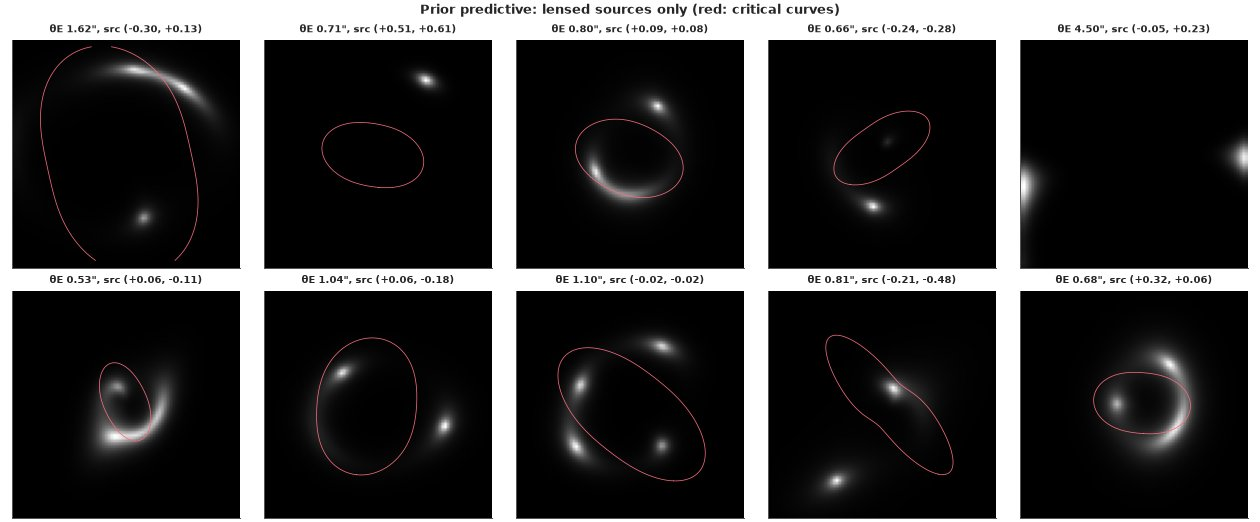

In [10]:
def prior_draw(r):
    th = np.array([0, 0, 0.4, 1.2, 2.5, 0.6, -0.1, 0, -0.03, -0.02,
                   np.exp(r.normal(0, 0.5)), *r.normal(0, 0.2, 2), *r.normal(0, 0.1, 2), *r.normal(0, 0.05, 2),
                   np.exp(r.normal(np.log(0.2), 0.5)), r.uniform(0.5, 4), *r.normal(0, 0.2, 2), *r.normal(0, 0.3, 2)])
    th[11:13] = np.clip(th[11:13], -0.6, 0.6)
    return th


fig, axs = plt.subplots(2, 5, figsize=(14, 5.8))
r_prior = np.random.default_rng(RANDOM_SEED)
for ax in axs.flat:
    th = prior_draw(r_prior)
    img = np.asarray(components(jnp.asarray(th))[2])
    ax.imshow(img, origin="lower", cmap="gray", extent=EXT)
    crit, caus, cut = critical_and_caustics(th[MASS])
    for ln in crit:
        ax.plot(ln[:, 0], ln[:, 1], color="C1", lw=0.6)
    ax.set_title(f"θE {th[10]:.2f}\", src ({th[21]:+.2f}, {th[22]:+.2f})", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Prior predictive: lensed sources only (red: critical curves)", fontsize=10)
show_jpeg(fig)

The prior allows everything from a single distorted image (a source far from the axis, or a lens
too light to make multiple images) through arcs and pairs of images to near-complete rings, and
Einstein radii from 0.5" to over 4". The data will have to pick. (The lens light and the amplitudes are
not part of this picture; the amplitudes have flat priors and are integrated out.)

## C. A model for every pixel

### Finding the mode - and the wrong modes

A lens posterior has many local optima: the source can sit on the wrong side of a caustic, the lens
centre can drift to put a ring through a different set of pixels, the lens light can absorb part of
the ring. First, the naive approach: maximise the likelihood from six starting points - the lens
light always from the same rough guess, the lens mass and the source drawn from the prior - with
L-BFGS on JAX gradients (the optimiser's box bounds are wide versions of the priors).

In [11]:
BOUNDS = ([(-0.2, 0.2)] * 2 + [(0.02, 3.0), (0.3, 10.0), (0.5, 8.0), (0.5, 8.0)] + [(-0.5, 0.5)] * 4 + [(0.5, 2.5)]
          + [(-0.5, 0.5)] * 2 + [(-0.2, 0.2)] * 2 + [(-0.2, 0.2)] * 2 + [(0.01, 1.0), (0.5, 8.0)] + [(-0.6, 0.6)] * 4)


def fd_hessian(value_grad, x, rel=1e-4):
    """Hessian by central differences of an exact (JAX) gradient: one gradient's memory, not 2n of them."""
    x = np.asarray(x, float)
    Hm = np.zeros((len(x), len(x)))
    for i in range(len(x)):
        e = np.zeros_like(x)
        e[i] = rel * max(abs(x[i]), 1.0)
        Hm[i] = (np.asarray(value_grad(x + e)[1]) - np.asarray(value_grad(x - e)[1])) / (2 * e[i])
    return (Hm + Hm.T) / 2


def maximise(fun_value_grad, th0):
    return optimize.minimize(lambda p: tuple(np.asarray(v) for v in fun_value_grad(p)), th0, jac=True,
                             method="L-BFGS-B", bounds=BOUNDS, options={"maxiter": 3000})


neg_ll = jax.jit(jax.value_and_grad(lambda p: -loglik(p)[0]))
tic = time.time()
starts, fits = [], []
r_start = np.random.default_rng(RANDOM_SEED + 1)
for k in range(6):
    th0 = prior_draw(r_start)
    th0[:10] = [0.0, 0.0, 0.4, 1.5, 2.0, 1.0, -0.05, 0.01, -0.05, 0.01]
    th0 = np.clip(th0, [b[0] + 1e-3 for b in BOUNDS], [b[1] - 1e-3 for b in BOUNDS])
    starts.append(th0)
    fits.append(maximise(neg_ll, th0))


def start_table(starts, fits):
    tab = pd.DataFrame({"start θE": [s[10] for s in starts], "start src x": [s[21] for s in starts],
                        "start src y": [s[22] for s in starts], "θE": [f.x[10] for f in fits],
                        "mass x": [f.x[13] for f in fits], "mass y": [f.x[14] for f in fits],
                        "src x": [f.x[21] for f in fits], "src y": [f.x[22] for f in fits],
                        "src R": [f.x[17] for f in fits], "-log L": [f.fun for f in fits]})
    return tab


tab_random = start_table(starts, fits)
print(tab_random.round(3).to_string())
print(f"six optimisations from random starts: {time.time() - tic:.0f} s")

   start θE  start src x  start src y     θE  mass x  mass y  src x  src y  src R     -log L
0     1.327        0.412        0.096  1.529   0.015   0.196  0.000  0.320  0.083   5740.265
1     0.501        0.169       -0.177  0.672   0.041   0.023  0.002  0.003  0.911   7679.905
2     2.499        0.174        0.285  1.973   0.200   0.200  0.374  0.600  0.162   6518.964
3     1.614       -0.072       -0.103  1.758   0.016   0.200 -0.016 -0.159  0.281   7919.264
4     0.501        0.445        0.035  0.588   0.065  -0.037  0.379 -0.015  0.676  10067.867
5     1.629        0.082       -0.231  1.216  -0.064  -0.200 -0.041 -0.117  1.000   3365.993
six optimisations from random starts: 19 s


Every random start ends in a wrong optimum, 780 to 7,500 log-likelihood units below the best fit we
find next. The closest (start 5) has about the right Einstein radius, but its mass centre ran into
the edge of the allowed box (0.2" south of the light) and its "source" is a huge, faint blob (the
upper bound on its size). The others found rings of the wrong size or put the lens far off-centre.
A factor $e^{-780}$ is not a competing explanation - but an optimiser, or a sampler chain, that
starts there never finds out.

### A staged start

Lens modellers do not start blind. They build the starting point in stages, each an easy problem:

1. **Fit the lens galaxy's light alone**, with the ring's annulus (0.8-1.7" from the centre) masked
   out - here by giving those pixels a huge noise.
2. **Read the Einstein radius off the ring**: in the image with that light model subtracted, the
   azimuthally averaged brightness peaks at the ring's radius, which for an isothermal lens is close
   to $\theta_E$.
3. **Start the lens mass at the light's centre**, round, with that $\theta_E$ and no shear, and the
   source small, near the axis - from a handful of positions, to see whether they agree.

In [12]:
tic = time.time()
in_ring = (np.hypot(*(np.indices((N, N)) - h)) * PIX > 0.8) & (np.hypot(*(np.indices((N, N)) - h)) * PIX < 1.7)
SIG_MASKED = jnp.asarray(np.where(in_ring, 1e3, sig))


def light_only_loglik(p):
    th = jnp.concatenate([p, jnp.asarray(TH_DUMMY_REST)])
    B = components(th)[jnp.array([0, 1, 3])]
    A = jax.vmap(whiten)(B / SIG_MASKED).reshape(3, -1).T
    b = whiten(D_J / SIG_MASKED).ravel()
    amp = jnp.linalg.solve(A.T @ A, A.T @ b)
    r = b - A @ amp
    return -0.5 * (r @ r), amp


TH_DUMMY_REST = np.array([1.0, 0.01, 0.01, 0, 0, 0, 0, 0.1, 1.0, 0.01, 0.01, 0, 0])   # mass/source: unused
vg_light = jax.jit(jax.value_and_grad(lambda p: -light_only_loglik(p)[0]))
fit_light = optimize.minimize(lambda p: tuple(np.asarray(v) for v in vg_light(p)),
                              np.array([0.0, 0.0, 0.4, 1.5, 2.0, 1.0, -0.05, 0.01, -0.05, 0.01]), jac=True,
                              method="L-BFGS-B", bounds=BOUNDS[:10])
LIGHT0 = fit_light.x
amp_l = np.asarray(light_only_loglik(jnp.asarray(LIGHT0))[1])
B_l = np.asarray(components(jnp.asarray(np.r_[LIGHT0, TH_DUMMY_REST])))[[0, 1, 3]]
sub0 = sci - np.tensordot(amp_l, B_l, 1)
rbin = np.arange(0.5, 1.9, 0.05)
rpix = np.hypot(*(np.indices((N, N)) - h)) * PIX
prof = np.array([sub0[(rpix >= r) & (rpix < r + 0.05)].mean() for r in rbin])
TE0 = rbin[np.argmax(prof)] + 0.025
print(f"stage 1-2: light fitted in {time.time() - tic:.0f} s; the ring's mean brightness peaks at r = {TE0:.3f}\"")

staged_starts, staged_fits = [], []
for sx, sy in [(0.0, 0.0), (0.15, 0.0), (-0.15, 0.0), (0.0, 0.15), (0.0, -0.15)]:
    th0 = np.r_[LIGHT0, TE0, 0.01, 0.01, LIGHT0[0], LIGHT0[1], 0.0, 0.0, 0.1, 1.0, 0.01, 0.01, sx, sy]
    staged_starts.append(th0)
    staged_fits.append(maximise(neg_ll, th0))
tab_staged = start_table(staged_starts, staged_fits)
best_all = min(tab_random["-log L"].min(), tab_staged["-log L"].min())
for t_ in (tab_random, tab_staged):
    t_["Δ(-log L) vs best"] = t_["-log L"] - best_all
print(tab_staged.round(3).to_string())
print(f"random starts, Δ(-log L) vs the best staged fit: {np.round(tab_random['Δ(-log L) vs best'].to_numpy(), 0)}")
print(f"stage 3: five optimisations, {time.time() - tic:.0f} s in all")
TH_ML = staged_fits[int(np.argmin([f.fun for f in staged_fits]))].x

stage 1-2: light fitted in 1 s; the ring's mean brightness peaks at r = 1.225"


   start θE  start src x  start src y     θE  mass x  mass y  src x  src y  src R    -log L  Δ(-log L) vs best
0     1.225         0.00         0.00  1.219  -0.062  -0.200 -0.037 -0.110  0.346  3395.599            809.625
1     1.225         0.15         0.00  1.223  -0.002  -0.006 -0.032 -0.156  0.136  2585.975              0.000
2     1.225        -0.15         0.00  1.223  -0.002  -0.006 -0.032 -0.156  0.136  2585.975              0.000
3     1.225         0.00         0.15  1.223  -0.002  -0.006 -0.032 -0.156  0.136  2585.975              0.000
4     1.225         0.00        -0.15  1.223  -0.002  -0.006 -0.032 -0.156  0.136  2585.976              0.002
random starts, Δ(-log L) vs the best staged fit: [3154. 5094. 3933. 5333. 7482.  780.]
stage 3: five optimisations, 7 s in all


The light fit and the ring's radius (1.225", from the azimuthal profile) put the start in the right
neighbourhood, and four of the five source positions converge to the same optimum, with
$\theta_E = 1.223"$ and the mass centred on the light. The fifth - the source started exactly on the
lens axis - slid into a wrong mode much like the best random start's (mass centre at the box edge),
810 units worse. Even a good staged start needs a few restarts, and the one with the highest
likelihood is the one to keep; every sampler chain below starts there.

Let us look at the best fit, and at the image with the model of the lens galaxy's light subtracted.

amplitudes (e-/s at the half-light radius; constant in e-/s): light1 1.0165, light2 0.1261, source 0.0918, constant 0.0605


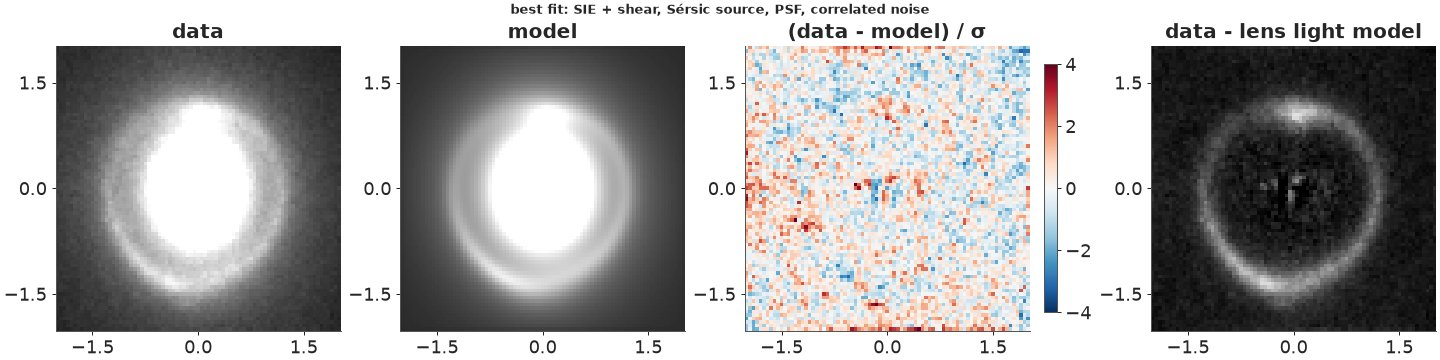

In [13]:
ll_ml, amp_ml = loglik(jnp.asarray(TH_ML))
amp_ml = np.asarray(amp_ml)
B_ml = np.asarray(components(jnp.asarray(TH_ML)))
light_ml = amp_ml[0] * B_ml[0] + amp_ml[1] * B_ml[1] + amp_ml[3] * B_ml[3]
model_ml = light_ml + amp_ml[2] * B_ml[2]
print("amplitudes (e-/s at the half-light radius; constant in e-/s):",
      ", ".join(f"{k} {v:.4f}" for k, v in zip(["light1", "light2", "source", "constant"], amp_ml)))


def panels(d, m, s, title, light=None):
    ncol = 4 if light is not None else 3
    fig, axs = plt.subplots(1, ncol, figsize=(4 * ncol, 4))
    kw = dict(origin="lower", extent=EXT)
    axs[0].imshow(d, cmap="gray", vmin=-0.02, vmax=0.5, **kw)
    axs[0].set_title("data")
    axs[1].imshow(m, cmap="gray", vmin=-0.02, vmax=0.5, **kw)
    axs[1].set_title("model")
    im = axs[2].imshow((d - m) / s, cmap="RdBu_r", vmin=-4, vmax=4, **kw)
    axs[2].set_title("(data - model) / σ")
    fig.colorbar(im, ax=axs[2], shrink=0.8)
    if light is not None:
        axs[3].imshow(d - light, cmap="gray", vmin=-0.03, vmax=0.3, **kw)
        axs[3].set_title("data - lens light model")
    for ax in axs:
        ax.set_xticks([-1.5, 0, 1.5])
        ax.set_yticks([-1.5, 0, 1.5])
    fig.suptitle(title, fontsize=10)
    return fig


show_jpeg(panels(sci, model_ml, sig, "best fit: SIE + shear, Sérsic source, PSF, correlated noise", light_ml))

The model reproduces the ring - including its brighter northern knot and the south-eastern arc - and
the residuals are close to noise, with a little structure left at the centre of the lens galaxy
(two Sérsics are not a perfect description of a giant elliptical's core) and faint arcs along the
ring (a real galaxy is not a smooth Sérsic; Part D relaxes that). The lens-subtracted image (right)
shows the ring clean: note how much of it was hidden under the lens galaxy's light.

### Failure 1: forgetting the telescope

What if we skip the PSF convolution - the model image is the sharp one?

no PSF: -log L = 4658 vs 2586 with the PSF (worse by 2072)
theta_E 1.212 vs 1.223"; source half-light radius 0.472 vs 0.136"; source Sersic n 1.79 vs 0.86


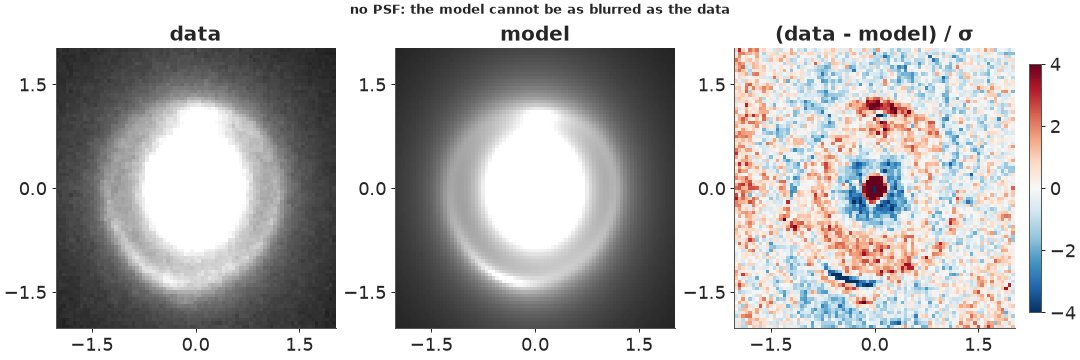

In [14]:
loglik_nopsf = make_loglik(use_psf=False)
fit_nopsf = maximise(jax.jit(jax.value_and_grad(lambda p: -loglik_nopsf(p)[0])), TH_ML)
TH_NOPSF = fit_nopsf.x
amp_np = np.asarray(loglik_nopsf(jnp.asarray(TH_NOPSF))[1])
model_np = model_image(TH_NOPSF, amp_np, use_psf=False)
print(f"no PSF: -log L = {fit_nopsf.fun:.0f} vs {-float(ll_ml):.0f} with the PSF "
      f"(worse by {fit_nopsf.fun + float(ll_ml):.0f})")
print(f"theta_E {TH_NOPSF[10]:.3f} vs {TH_ML[10]:.3f}\"; source half-light radius {TH_NOPSF[17]:.3f} vs {TH_ML[17]:.3f}\"; "
      f"source Sersic n {TH_NOPSF[18]:.2f} vs {TH_ML[18]:.2f}")
show_jpeg(panels(sci, model_np, sig, "no PSF: the model cannot be as blurred as the data"))

Without the PSF the fit is worse by about 2,000 log-likelihood units, and it shows: the centre of
the lens galaxy leaves a strong positive core ringed by negative residuals (a sharp model cannot
match a blurred core and its surroundings at once), and the ring leaves paired residuals along its
edges. The fit compensates by making the source **three to four times larger** (to blur the ring the
way the PSF would) - a badly biased picture of the background galaxy. The Einstein radius moves
far less, by 1% (0.011"): it is set mainly by *where* the ring is, and a symmetric blur hardly moves
that. But 1% is about nine times the posterior sd we find below, so it is a bias, not noise. That
pattern - robust $\theta_E$, fragile everything else - will come back.

### Failure 2: independent pixels

The likelihood above whitens the correlated noise. Treating pixels as independent is a one-word
change. Here we compare the two by the curvature of the log-likelihood at the optimum (a Laplace
approximation), which is cheap and good enough for the question "how wide":

In [15]:
loglik_indep = make_loglik(white=False)
fit_indep = maximise(jax.jit(jax.value_and_grad(lambda p: -loglik_indep(p)[0])), TH_ML)
sds = {}
for lab, f, x in [("whitened (correlated noise)", loglik, TH_ML), ("independent pixels", loglik_indep, fit_indep.x)]:
    Hs = fd_hessian(jax.jit(jax.value_and_grad(lambda p: -f(p)[0])), x)
    sds[lab] = np.sqrt(np.diag(np.linalg.inv(Hs)))
sd_tab = pd.DataFrame(sds, index=NAMES).loc[["theta_E", "e1_mass", "e2_mass", "gamma1", "gamma2", "x_mass", "R_src"]]
sd_tab["ratio"] = sd_tab.iloc[:, 0] / sd_tab.iloc[:, 1]
print(sd_tab.round(4))

         whitened (correlated noise)  independent pixels   ratio
theta_E                       0.0014              0.0009  1.4241
e1_mass                       0.0045              0.0031  1.4240
e2_mass                       0.0049              0.0034  1.4248
gamma1                        0.0026              0.0018  1.4185
gamma2                        0.0031              0.0022  1.4244
x_mass                        0.0022              0.0016  1.4310
R_src                         0.0042              0.0030  1.4082


Treating the pixels as independent gives error bars that are too small by a factor of about 1.4 -
close to $\sqrt{2.1}$, the square root of the summed noise correlation measured in Part A. The best
fit hardly changes. This is a failure that no residual plot shows: the model fits equally well; only
its uncertainty is wrong.

### The posterior with NUTS

Now the full model in PyMC. The likelihood is the JAX function above, wrapped with
`pytensor.wrap_jax` so PyMC gets values and gradients from JAX; the priors are ordinary PyMC
distributions. Sampling runs through nutpie with the model compiled to JAX. Lens models have
strongly correlated parameters (the ellipticity of the mass trades off against the external shear;
the lens centre against the source position; the source's size against its Sérsic index), so we use
nutpie's **low-rank mass-matrix adaptation**, which learns the main correlation directions during
warm-up. All chains start at the best optimum, with nutpie's random start jitter switched off:
one unit of jitter on the unconstrained scale would throw a chain into a wrong mode.

In [16]:
@wrap_jax
def image_loglik(th, s):
    return loglik(th, s)[0]


with pm.Model() as lens_model:
    xy_light = pm.Normal("xy_light", 0.0, 0.1, shape=2)
    R_light = pm.LogNormal("R_light", np.log([0.5, 1.5]), 1.0, shape=2)
    n_light = pm.Uniform("n_light", 0.5, 8.0, shape=2)
    e_light = pm.Normal("e_light", 0.0, 0.2, shape=(2, 2))
    theta_E = pm.LogNormal("theta_E", 0.0, 0.5)
    e_mass = pm.Normal("e_mass", 0.0, 0.2, shape=2)
    xy_mass = pm.Normal("xy_mass", 0.0, 0.1, shape=2)
    shear = pm.Normal("shear", 0.0, 0.05, shape=2)
    R_src = pm.LogNormal("R_src", np.log(0.2), 0.5)
    n_src = pm.Uniform("n_src", 0.5, 8.0)
    e_src = pm.Normal("e_src", 0.0, 0.2, shape=2)
    xy_src = pm.Normal("xy_src", 0.0, 0.3, shape=2)
    noise_scale = pm.LogNormal("noise_scale", 0.0, 0.2)
    th = pt.stack([xy_light[0], xy_light[1], R_light[0], R_light[1], n_light[0], n_light[1], e_light[0, 0],
                   e_light[0, 1], e_light[1, 0], e_light[1, 1], theta_E, e_mass[0], e_mass[1], xy_mass[0],
                   xy_mass[1], shear[0], shear[1], R_src, n_src, e_src[0], e_src[1], xy_src[0], xy_src[1]])
    pm.Potential("image", image_loglik(pt.specify_shape(th, (23,)), noise_scale))


def as_initvals(x):
    x = np.asarray(x, float).copy()
    x[4:6] = np.clip(x[4:6], 0.52, 7.9)
    x[18] = np.clip(x[18], 0.52, 7.9)
    return {"xy_light": x[0:2], "R_light": x[2:4], "n_light": x[4:6], "e_light": x[6:10].reshape(2, 2),
            "theta_E": x[10], "e_mass": x[11:13], "xy_mass": x[13:15], "shear": x[15:17], "R_src": x[17],
            "n_src": x[18], "e_src": x[19:21], "xy_src": x[21:23], "noise_scale": 0.9}


tic = time.time()
with lens_model:
    idata = pm.sample(draws=600, tune=400, chains=4, initvals=as_initvals(TH_ML), random_seed=RANDOM_SEED,
                      progressbar=False, nuts={"adaptation": "low_rank"}, target_accept=0.9,
                      compile_kwargs={"backend": "jax", "gradient_backend": "jax", "jitter_rvs": set()})
print(f"NUTS: {time.time() - tic:.0f} s; warm-up {idata.posterior.attrs.get('tuning_steps')} steps")
ss = idata.sample_stats
div = ss["diverging"].values.ravel()
n2 = idata.posterior["n_light"].values[..., 1].ravel()
print(f"divergences {int(div.sum())}; tree depth counts {np.bincount(ss['depth'].values.ravel())}")
print(f"n_light[1] at divergent draws: {np.round(n2[div], 3)}; its 5% quantile over all draws: {np.quantile(n2, 0.05):.3f}")
summ = pd.concat([az.summary(idata, var_names=[v], round_to=4) for v in
                  ["theta_E", "e_mass", "shear", "xy_mass", "xy_light", "R_src", "n_src", "xy_src", "n_light",
                   "noise_scale"]])
print(summ[["mean", "sd", "ess_bulk", "ess_tail", "r_hat"]])
rh = az.rhat(idata).to_dataset().to_dataarray().max().item()
print(f"largest r_hat over all parameters: {rh:.3f}")

NUTS: 146 s; warm-up 400 steps
divergences 1; tree depth counts [   0    0    0  671 1728    1]
n_light[1] at divergent draws: [0.568]; its 5% quantile over all draws: 0.501
               mean      sd   ess_bulk   ess_tail   r_hat
theta_E      1.2231  0.0012  3869.6304  1431.4952  0.9995
e_mass[0]   -0.0874  0.0041  3599.3346  1434.5374  1.0014
e_mass[1]   -0.0043  0.0041  3785.4264  1977.9496  1.0036
shear[0]    -0.0256  0.0023  3740.9273  1697.2749  1.0012
shear[1]     0.0049  0.0026  3735.2629  2034.1129  1.0022
xy_mass[0]  -0.0022  0.0020  4541.0701  2045.8072  1.0022
xy_mass[1]  -0.0056  0.0029  2921.6762  1690.7274  1.0041
xy_light[0] -0.0045  0.0002  3735.7114  1945.0228  1.0006
xy_light[1] -0.0153  0.0003  3359.8493  1945.1408  1.0003
R_src        0.1380  0.0036  2778.7756  1713.5132  0.9999
n_src        0.8728  0.0390  3305.6225  1504.6831  1.0002
xy_src[0]   -0.0324  0.0020  3902.4052  1537.4665  1.0019
xy_src[1]   -0.1554  0.0019  3746.7820  1664.7318  1.0037
n_light[0]   2

The sampler is healthy. We raised `target_accept` to 0.9 after a first run at the default 0.8 gave a
handful of divergences; now there is a single divergence in 2,400 draws, at an unremarkable point
(not at the Sérsic-index bound we first suspected: the check is printed). Trees have depth 3-4
(7-15 gradient evaluations per draw: the low-rank mass matrix has absorbed most of the
correlations), $\hat R \le 1.01$ everywhere, and effective sample sizes are in the thousands -
except the second light component's index, which still has several hundred. Some things to read off:

* $\theta_E = 1.2231"$ with a posterior sd of 0.0012" - a **0.1%** measurement from one image. That
  is the *statistical* uncertainty given this model; Part D shows a different source model moving it
  by twice that.
* The mass is flattened ($e_1 \approx -0.087$, i.e. axis ratio $q \approx 0.84$) with a small
  external shear (about 0.026); the mass centre is within 0.01" (a fifth of a pixel) of the light
  centre - we did not force them to coincide.
* The noise scale is 0.885: our noise map overestimated the noise by about 13%. The likely culprit is
  the photon term: drizzling averages each output pixel over several input pixels, which lowers its
  own photon noise just as it lowered the sky's.
* The source is compact (half-light radius 0.14", Sérsic $n \approx 0.87$, close to an exponential
  disc) and sits 0.15" south of the lens centre.
* The second lens-light component sits at the lower bound of its Sérsic index ($n = 0.5$, a Gaussian):
  it acts as a broad, flat-topped halo. It is a nuisance description, and the bound is harmless.

### Posterior predictive check

In a whitened, correctly specified model, the whitened residuals are independent $N(0, s^2)$. We
check their distribution and look for structure by azimuthal sector along the ring, where a wrong
lens would leave systematic residuals.

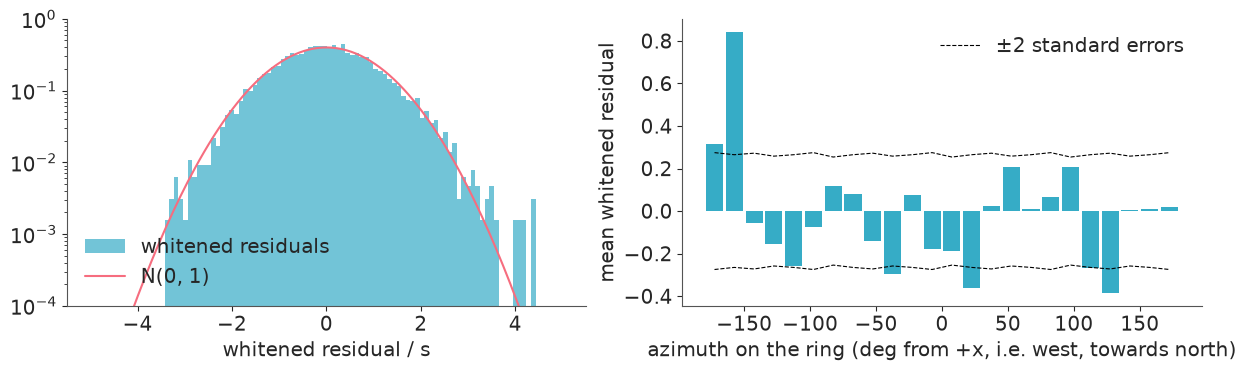

whitened residuals: sd 0.998, fraction beyond ±4: 0.0006 (normal: 0.0001); ring sectors outside ±2 SE: 6 of 24


In [17]:
def draws_matrix(idata, n=None, seed=RANDOM_SEED):
    """Posterior draws as an (n, 23) matrix in the order of NAMES (plus the noise scale)."""
    p = idata.posterior
    stack = lambda v: p[v].values.reshape(p.sizes["chain"] * p.sizes["draw"], -1)
    M = np.column_stack([stack("xy_light"), stack("R_light"), stack("n_light"), stack("e_light"), stack("theta_E"),
                         stack("e_mass"), stack("xy_mass"), stack("shear"), stack("R_src"), stack("n_src"),
                         stack("e_src"), stack("xy_src")])
    s = stack("noise_scale")[:, 0]
    if n is not None:
        idx = np.random.default_rng(seed).choice(len(M), n, replace=False)
        M, s = M[idx], s[idx]
    return M, s


TH_ALL, S_ALL = draws_matrix(idata)
TH_MEAN = TH_ALL.mean(axis=0)
S_MED = float(np.median(S_ALL))
amp_mean = np.asarray(loglik(jnp.asarray(TH_MEAN), S_MED)[1])
model_mean = model_image(TH_MEAN, amp_mean)
B_mean = np.asarray(components(jnp.asarray(TH_MEAN)))
light_mean = amp_mean[0] * B_mean[0] + amp_mean[1] * B_mean[1] + amp_mean[3] * B_mean[3]
wres = whiten_np((sci - model_mean) / sig) / S_MED
yy, xx = (np.indices((N, N)) - h) * PIX
rad, azi = np.hypot(xx, yy), np.degrees(np.arctan2(yy, xx))
on_ring = (rad > 1.0) & (rad < 1.45)

fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
axs[0].hist(wres.ravel(), bins=80, density=True, color="C0", alpha=0.7, label="whitened residuals")
z = np.linspace(-5, 5, 200)
axs[0].plot(z, np.exp(-z**2 / 2) / np.sqrt(2 * np.pi), color="C1", label="N(0, 1)")
axs[0].set(yscale="log", ylim=(1e-4, 1), xlabel="whitened residual / s")
axs[0].legend()
sect = np.arange(-180, 181, 15)
mres = [wres[on_ring & (azi >= a) & (azi < a + 15)].mean() for a in sect[:-1]]
nsec = [np.sum(on_ring & (azi >= a) & (azi < a + 15)) for a in sect[:-1]]
axs[1].bar(sect[:-1] + 7.5, mres, width=13, color="C0")
axs[1].plot(sect[:-1] + 7.5, 2 / np.sqrt(nsec), "k--", lw=0.8)
axs[1].plot(sect[:-1] + 7.5, -2 / np.sqrt(nsec), "k--", lw=0.8, label="±2 standard errors")
axs[1].set(xlabel="azimuth on the ring (deg from +x, i.e. west, towards north)", ylabel="mean whitened residual")
axs[1].legend()
plt.show()
print(f"whitened residuals: sd {wres.std():.3f}, fraction beyond ±4: {np.mean(np.abs(wres) > 4):.4f} "
      f"(normal: {2 * 3.17e-5:.4f}); ring sectors outside ±2 SE: {np.sum(np.abs(mres) > 2 / np.sqrt(nsec))} of {len(mres)}")

The whitened residuals have unit spread and a normal core; their tails are heavier than normal
(0.06% of pixels beyond ±4 against 0.006% expected) - a few pixels at the lens galaxy's centre and on
the ring. Along the ring, 6 of 24 sectors are more than two standard errors from zero where about one
would be by chance: the east side (azimuths -150 to -180 degrees) is brighter than the model, and
sectors to the north-east, west-north-west and south-west are fainter. The lens may be fine; the
source is not a smooth Sérsic ellipse. That is the next part.

## D. What does the background galaxy look like? A pixelated source

A Sérsic profile is a smooth, symmetric blob. The residual arcs along the ring say the real source
has more structure. The standard remedy (Warren & Dye 2003; Suyu et al. 2006) is to describe the
source by the brightness in each pixel of a **grid in the source plane** - here 30 x 30 pixels of
0.031" over a 0.9" box around the source - and let the data decide.

For a fixed lens, each source pixel maps to a fixed pattern of image pixels (ray tracing, bilinear
interpolation, PSF, whitening): the image is **linear** in the source, $\mathbf d = \mathbf F\mathbf s +
\text{noise}$. With 900 source pixels and a few thousand image pixels on the ring, the least-squares
solution would fit the noise, so the source gets a Gaussian prior that prefers smoothness,

$$p(\mathbf s\mid\lambda) \propto \exp\left(-\tfrac{\lambda}{2}\,\mathbf s^\top\mathbf H\,\mathbf s\right),$$

where $\mathbf s^\top\mathbf H\mathbf s$ is a sum of squared differences between neighbouring pixels
("gradient" regularisation) or of squared discrete Laplacians ("curvature"). Prior and likelihood are
both Gaussian, so everything is exact:

* the source posterior is Gaussian, with precision $\mathbf A = \mathbf F^\top\mathbf F + \lambda\mathbf H$
  and mean $\hat{\mathbf s} = \mathbf A^{-1}\mathbf F^\top\mathbf d$;
* the source can be **integrated out**, giving the marginal likelihood - the **evidence** - of the
  lens parameters and $\lambda$:

$$\log p(\mathbf d\mid\text{lens}, \lambda) = -\tfrac12\|\mathbf d - \mathbf F\hat{\mathbf s}\|^2
  - \tfrac{\lambda}{2}\hat{\mathbf s}^\top\mathbf H\hat{\mathbf s} - \tfrac12\log\det\mathbf A
  + \tfrac12\log\det(\lambda\mathbf H) + \text{const}.$$

The evidence balances fit against the prior volume, and so chooses $\lambda$ - and the form of
$\mathbf H$ - without any held-out data. It is also a smooth function of the lens parameters, so
the lens can be refitted with the source marginalised: that is "using the full image" in its purest
form. We keep the lens light fixed at the posterior mean from Part C and use the image pixels in an
annulus 0.6-1.9" from the centre (after whitening; the whitened residuals are independent, so a
subset of them is still a proper likelihood). The noise map is scaled by the posterior median of $s$.

In [18]:
G, HW = 30, 0.45                                     # source grid: G x G pixels over +-HW arcsec
SRC_C = TH_MEAN[21:23].copy()                        # centred on the Sersic source
DP = 2 * HW / (G - 1)
SRC_AX = SRC_C[0] - HW + DP * np.arange(G), SRC_C[1] - HW + DP * np.arange(G)
ANNULUS = (rad > 0.6) & (rad < 1.9)
MI = np.nonzero(ANNULUS.ravel())[0]
PIX_OF_RAY = jnp.asarray(((np.arange(N * SUB)[:, None] // SUB) * N + (np.arange(N * SUB)[None, :] // SUB)).ravel())
SIG_S = jnp.asarray(sig * S_MED)


def reg_matrix(kind):
    I = np.eye(G)
    if kind == "gradient":                   # differences to the right/up neighbour (zero outside the grid)
        Dm = np.eye(G) - np.eye(G, k=1)
    elif kind == "curvature":                # discrete second differences
        Dm = 2 * np.eye(G) - np.eye(G, k=1) - np.eye(G, k=-1)
    else:
        return np.eye(G * G)
    Dx, Dy = np.kron(I, Dm), np.kron(Dm, I)
    return Dx.T @ Dx + Dy.T @ Dy


def response(mass):
    """F: whitened image-pixel response (annulus pixels x G*G) to each source pixel, for a given lens."""
    ax, ay = deflection(XS, YS, mass)
    u = ((XS - ax).ravel() - SRC_AX[0][0]) / DP
    v = ((YS - ay).ravel() - SRC_AX[1][0]) / DP
    i0, j0 = jnp.floor(u), jnp.floor(v)
    fu, fv = u - i0, v - j0
    i0, j0 = i0.astype(int), j0.astype(int)
    M = jnp.zeros((N * N, G * G))
    for di, dj, w in [(0, 0, (1 - fu) * (1 - fv)), (1, 0, fu * (1 - fv)), (0, 1, (1 - fu) * fv), (1, 1, fu * fv)]:
        ii, jj = i0 + di, j0 + dj
        ok = (ii >= 0) & (ii < G) & (jj >= 0) & (jj < G)
        M = M.at[PIX_OF_RAY, jnp.where(ok, jj * G + ii, 0)].add(jnp.where(ok, w, 0.0) / SUB**2)
    cols = convolve(M.T.reshape(G * G, N, N)) / SIG_S
    return jax.vmap(whiten)(cols).reshape(G * G, N * N)[:, MI].T


def data_vector(light):
    return jnp.asarray(whiten_np((sci - light) / (sig * S_MED)).ravel()[MI])


def evidence(mass, log_lam, H, dvec):
    F = response(mass)
    lam = jnp.exp(log_lam)
    A = F.T @ F + lam * H
    L = jnp.linalg.cholesky(A)
    s = jax.scipy.linalg.cho_solve((L, True), F.T @ dvec)
    r = dvec - F @ s
    logdet_A = 2 * jnp.sum(jnp.log(jnp.diag(L)))
    logdet_lH = jnp.linalg.slogdet(H)[1] + H.shape[0] * log_lam
    return -0.5 * (r @ r) - 0.5 * lam * (s @ H @ s) - 0.5 * logdet_A + 0.5 * logdet_lH, s, L


evidence_j = jax.jit(evidence)
D_VEC = data_vector(light_mean)
MASS_MEAN = TH_MEAN[MASS]
HS = {k: jnp.asarray(reg_matrix(k)) for k in ["identity", "gradient", "curvature"]}
LOG_LAMS = np.arange(-2, 12.1, 0.5)
tic = time.time()
ev_curves = {k: np.array([float(evidence_j(MASS_MEAN, ll_, H, D_VEC)[0]) for ll_ in LOG_LAMS]) for k, H in HS.items()}
print(f"evidence on a grid of lambda, three regularisations: {time.time() - tic:.0f} s")
best_reg = {k: (LOG_LAMS[np.argmax(v)], v.max()) for k, v in ev_curves.items()}
for k, (l_, e_) in best_reg.items():
    print(f"{k:>9}: best log lambda {l_:4.1f}, log evidence {e_:9.1f}  ({e_ - best_reg['curvature'][1]:+.1f} vs curvature)")

evidence on a grid of lambda, three regularisations: 11 s
 identity: best log lambda  5.0, log evidence   -2189.6  (-218.1 vs curvature)
 gradient: best log lambda  6.0, log evidence   -1978.1  (-6.6 vs curvature)
curvature: best log lambda  6.5, log evidence   -1971.6  (+0.0 vs curvature)


The evidence has a clear maximum in $\lambda$ for each form of prior, and it ranks the forms:
curvature regularisation (smooth second differences) wins, gradient regularisation is 7 log units
behind - a Bayes factor of several hundred, but a modest one by the standards of this image - and
the "identity" prior (independent pixels, no smoothness) is over 200 units worse, at the bottom of
the plot. The data prefer a source with smoothly varying brightness.

To see what the evidence is protecting us from, here are the source reconstructions at the optimum
and far on either side of it:

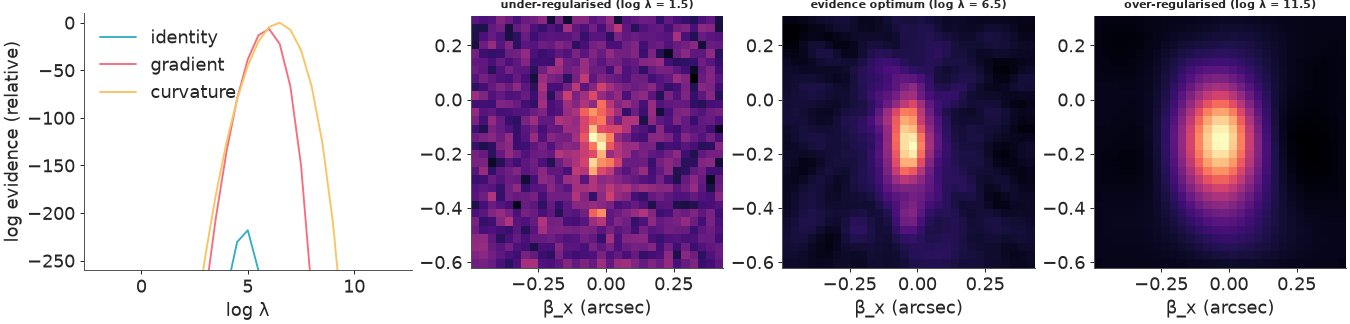

In [19]:
H_C = HS["curvature"]
LL_BEST = best_reg["curvature"][0]
fig, axs = plt.subplots(1, 4, figsize=(15, 3.6), gridspec_kw={"width_ratios": [1.3, 1, 1, 1]})
for k, v in ev_curves.items():
    axs[0].plot(LOG_LAMS, v - best_reg["curvature"][1], label=k)
axs[0].set(ylim=(-260, 10), xlabel="log λ", ylabel="log evidence (relative)")
axs[0].legend()
for ax, (lab, ll_) in zip(axs[1:], [("under-regularised", LL_BEST - 5), ("evidence optimum", LL_BEST),
                                    ("over-regularised", LL_BEST + 5)]):
    s_ = np.asarray(evidence_j(MASS_MEAN, ll_, H_C, D_VEC)[1]).reshape(G, G)
    ax.imshow(s_, origin="lower", cmap="magma", extent=[SRC_AX[0][0] - DP / 2, SRC_AX[0][-1] + DP / 2,
                                                         SRC_AX[1][0] - DP / 2, SRC_AX[1][-1] + DP / 2])
    ax.set_title(f"{lab} (log λ = {ll_:.1f})", fontsize=9)
    ax.set(xlabel="β_x (arcsec)")
show_jpeg(fig)

Too little regularisation and the source is noise - each source pixel fits a few noisy image
pixels; too much and it is a smooth blob. The evidence optimum sits in between, and shows an
elongated galaxy with a bright compact core and fainter extended light.

### Refitting the lens with the source integrated out

The evidence is differentiable in the lens parameters (JAX differentiates through the ray tracing,
the interpolation weights, the FFTs and the Cholesky factorisation), so we can maximise it over the
seven mass parameters and $\log\lambda$ together, and use its curvature at the optimum for error
bars (Laplace). One evaluation with its gradient takes a fraction of a second - too slow for NUTS
within this notebook's budget, fine for an optimiser.

In [20]:
tic = time.time()
neg_ev = jax.jit(jax.value_and_grad(lambda p: -evidence(p[:7], p[7], H_C, D_VEC)[0]))
fit_pix = optimize.minimize(lambda p: tuple(np.asarray(v) for v in neg_ev(p)), np.r_[MASS_MEAN, LL_BEST],
                            jac=True, method="L-BFGS-B")
hess_pix = fd_hessian(neg_ev, fit_pix.x)
sd_pix = np.sqrt(np.diag(np.linalg.inv(hess_pix)))
print(f"evidence refit: {time.time() - tic:.0f} s, {fit_pix.nit} iterations; log evidence "
      f"{-fit_pix.fun:.1f} (at the Sersic-model lens: {best_reg['curvature'][1]:.1f})")
MASS_PIX, LL_PIX = fit_pix.x[:7], fit_pix.x[7]
cmp = pd.DataFrame({"Sérsic source (NUTS mean ± sd)": [f"{m:.4f} ± {s:.4f}" for m, s in
                                                     zip(TH_ALL[:, MASS].mean(0), TH_ALL[:, MASS].std(0))],
                    "pixelated source (Laplace)": [f"{m:.4f} ± {s:.4f}" for m, s in zip(MASS_PIX, sd_pix[:7])],
                    "difference / Sérsic sd": (MASS_PIX - TH_ALL[:, MASS].mean(0)) / TH_ALL[:, MASS].std(0)},
                   index=NAMES[MASS])
print(cmp.round(1).to_string())
print(f"log lambda {LL_PIX:.2f} ± {sd_pix[7]:.2f}")

evidence refit: 16 s, 26 iterations; log evidence -1963.2 (at the Sersic-model lens: -1971.6)
        Sérsic source (NUTS mean ± sd) pixelated source (Laplace)  difference / Sérsic sd
theta_E                1.2231 ± 0.0012            1.2253 ± 0.0012                     1.9
e1_mass               -0.0874 ± 0.0041           -0.0833 ± 0.0044                     1.0
e2_mass               -0.0043 ± 0.0041           -0.0153 ± 0.0052                    -2.7
x_mass                -0.0022 ± 0.0020           -0.0063 ± 0.0020                    -2.0
y_mass                -0.0056 ± 0.0029            0.0062 ± 0.0029                     4.0
gamma1                -0.0256 ± 0.0023           -0.0240 ± 0.0024                     0.7
gamma2                 0.0049 ± 0.0026           -0.0019 ± 0.0033                    -2.6
log lambda 6.50 ± 0.15


With the source free to take any (smooth) shape, the lens moves: $\theta_E$ by +0.002" (about two
posterior sds of the Sérsic-source fit), the mass centre by 0.012" in $y$ (four sds), and the
ellipticity and shear components by up to 2.7 sds. The log evidence improves by 8. None of this is a
large change - $\theta_E$ agrees to 0.2% - but it is larger than the statistical uncertainty of
either fit. The posterior sd of one model is **not** the uncertainty of the measurement: the choice of
source model adds an error of the same size or larger. (Bolton et al. 2008 adopted a 2% empirical error
on $\theta_E$ for exactly this reason, from the scatter between independent modelling methods.)

### The unlensed galaxy, with its uncertainty

The source has two layers of uncertainty: given a lens, the Gaussian posterior of the pixels
(precision $\mathbf A$); and the lens itself. We propagate both. For 60 posterior draws of the lens
(and its light) from the NUTS run, we solve for the source at the evidence-optimal $\lambda$ and add
a draw from its Gaussian posterior. Mean and standard deviation over these draws are shown below,
together with the caustics of each lens draw.

60 source reconstructions: 8 s
peak brightness 0.298; posterior sd at the peak 0.011 (within-lens 0.011, between lens draws 0.004); typical sd 0.014


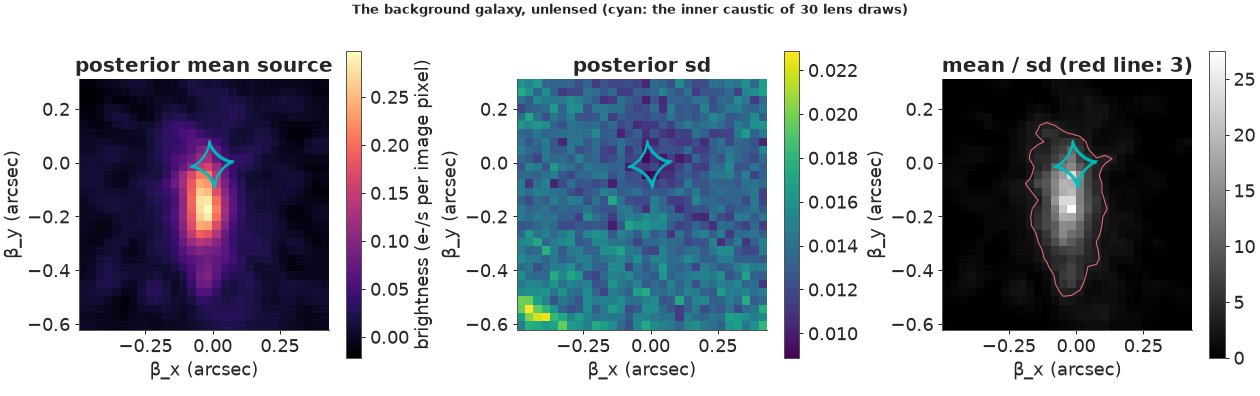

In [21]:
tic = time.time()
TH_60, S_60 = draws_matrix(idata, n=60)
src_draws, src_means, caustic_draws, crit_draws = [], [], [], []
r_src = np.random.default_rng(RANDOM_SEED + 2)
for th_d in TH_60:
    a_d = np.asarray(loglik(jnp.asarray(th_d), S_MED)[1])
    B_d = np.asarray(components(jnp.asarray(th_d)))
    dvec = data_vector(a_d[0] * B_d[0] + a_d[1] * B_d[1] + a_d[3] * B_d[3])
    _, s_hat, L = evidence_j(jnp.asarray(th_d[MASS]), LL_PIX, H_C, dvec)
    z = r_src.standard_normal(G * G)
    s_draw = np.asarray(s_hat) + np.asarray(jax.scipy.linalg.solve_triangular(L.T, z, lower=False))
    src_means.append(np.asarray(s_hat).reshape(G, G))
    src_draws.append(s_draw.reshape(G, G))
    crit, caus, cut = critical_and_caustics(th_d[MASS])
    crit_draws.append(crit)
    caustic_draws.append((caus, cut))
src_draws, src_means = np.array(src_draws), np.array(src_means)
print(f"60 source reconstructions: {time.time() - tic:.0f} s")
sd_within = np.sqrt(np.mean((src_draws - src_means) ** 2, axis=0))
sd_between = src_means.std(axis=0)
print(f"peak brightness {src_draws.mean(0).max():.3f}; posterior sd at the peak {src_draws.std(0).flat[np.argmax(src_draws.mean(0))]:.3f} "
      f"(within-lens {sd_within.flat[np.argmax(src_draws.mean(0))]:.3f}, between lens draws {sd_between.flat[np.argmax(src_draws.mean(0))]:.3f}); "
      f"typical sd {np.median(src_draws.std(0)):.3f}")

EXT_S = [SRC_AX[0][0] - DP / 2, SRC_AX[0][-1] + DP / 2, SRC_AX[1][0] - DP / 2, SRC_AX[1][-1] + DP / 2]
fig, axs = plt.subplots(1, 3, figsize=(14, 4.4))
mean_s, sd_s = src_draws.mean(0), src_draws.std(0)
im = axs[0].imshow(mean_s, origin="lower", cmap="magma", extent=EXT_S)
fig.colorbar(im, ax=axs[0], shrink=0.85, label="brightness (e-/s per image pixel)")
axs[0].set_title("posterior mean source")
im = axs[1].imshow(sd_s, origin="lower", cmap="viridis", extent=EXT_S)
fig.colorbar(im, ax=axs[1], shrink=0.85)
axs[1].set_title("posterior sd")
im = axs[2].imshow(mean_s / sd_s, origin="lower", cmap="gray", extent=EXT_S, vmin=0)
fig.colorbar(im, ax=axs[2], shrink=0.85)
axs[2].contour(SRC_AX[0], SRC_AX[1], mean_s / sd_s, levels=[3], colors="C1", linewidths=0.8)
axs[2].set_title("mean / sd (red line: 3)")
for ax in axs:
    for caus, cut in caustic_draws[:30]:
        for cl in caus:
            ax.plot(cl[:, 0], cl[:, 1], color="c", lw=0.4, alpha=0.5)
    ax.set(xlim=EXT_S[:2], ylim=EXT_S[2:], xlabel="β_x (arcsec)", ylabel="β_y (arcsec)")
fig.suptitle("The background galaxy, unlensed (cyan: the inner caustic of 30 lens draws)", fontsize=10)
show_jpeg(fig)

The background galaxy is elongated north-south, about 0.6" long where it is detected at three posterior
sds (about 4 kpc at its redshift - but see Part E on what "size" means here) and 0.15" wide, with a
bright core near (-0.03", -0.17"). The lens's diamond-shaped caustic covers its northern tip: that
part of the galaxy is imaged four times, and it is the bright knot at the top of the ring; the rest
lies outside the diamond but inside the radial cut (about 0.9" from the centre, off this plot), so it
is imaged twice, into the rest of the ring. The posterior sd is nearly uniform, about 0.014, rising
towards the corner of the grid that few image pixels see. At the brightest pixel the uncertainty is
almost all noise given the lens (0.011) rather than uncertainty about the lens (0.004): the lens is so
well pinned down that the 30 caustics drawn here lie on top of each other.

**A hypothetical-outcome animation.** A mean and an sd map hide how the uncertainty is *shaped*:
are the draws shifted, rescaled, or noisy? The animation shows one posterior draw of the unlensed
galaxy per frame - every frame is a picture the data allow - with that draw's caustic.

In [22]:
fig, ax = plt.subplots(figsize=(4.6, 4.2), dpi=72)
vmax = np.percentile(src_draws, 99.5)
frame = ax.imshow(src_draws[0], origin="lower", cmap="magma", extent=EXT_S, vmin=-0.1 * vmax, vmax=vmax)
lines = [ax.plot([], [], color="c", lw=0.8)[0] for _ in range(2)]
ax.set(xlim=EXT_S[:2], ylim=EXT_S[2:], xlabel="β_x (arcsec)", ylabel="β_y (arcsec)")


def update(k):
    frame.set_data(src_draws[k])
    caus, cut = caustic_draws[k]
    lines[0].set_data(caus[0][:, 0], caus[0][:, 1]) if caus else lines[0].set_data([], [])
    lines[1].set_data(cut[:, 0], cut[:, 1])
    ax.set_title(f"posterior draw {k + 1} of the unlensed galaxy", fontsize=9)
    return (frame, *lines)


anim = animation.FuncAnimation(fig, update, frames=range(40), interval=350)
plt.close(fig)
old_fmt = plt.rcParams["animation.frame_format"]
plt.rcParams["animation.frame_format"] = "jpeg"
display(HTML(anim.to_jshtml(default_mode="loop")))
plt.rcParams["animation.frame_format"] = old_fmt

From frame to frame the core and the elongation stay put while the faint outskirts change their
texture - the shape of the galaxy is secure, its faint structure (a knot here, a tail there) is at the
level of the noise. The caustic hardly moves.

## E. What the image cannot tell us: the mass-sheet degeneracy

Take any lens model and replace its convergence by

$$\kappa_\lambda(\boldsymbol\theta) = \lambda\,\kappa(\boldsymbol\theta) + (1 - \lambda),$$

i.e. scale the lens by $\lambda$ and add a uniform sheet of mass. The deflection becomes
$\boldsymbol\alpha_\lambda = \lambda\boldsymbol\alpha + (1-\lambda)\boldsymbol\theta$, so the lens
equation gives

$$\boldsymbol\beta_\lambda = \boldsymbol\theta - \boldsymbol\alpha_\lambda = \lambda\,(\boldsymbol\theta - \boldsymbol\alpha)
  = \lambda\,\boldsymbol\beta.$$

Every ray lands at the same place in a source plane that has been **uniformly rescaled** by
$\lambda$. If the source is also rescaled - same brightness, $\lambda$ times the size, at $\lambda$
times the position - every image pixel is *exactly* the same (Falco, Gorenstein & Shapiro 1985).
No amount of imaging data can distinguish the members of this family. We check it on the fitted
model:

In [23]:
def sheet_image(th, lam):
    t = np.asarray(th, float).copy()
    t[17], t[21], t[22] = lam * t[17], lam * t[21], lam * t[22]       # the source, rescaled by lambda
    B = np.asarray(components(jnp.asarray(t), mass_sheet=lam))
    return np.tensordot(amp_mean, B, 1)


base = sheet_image(TH_MEAN, 1.0)
for lam in [0.7, 0.85, 1.15, 1.3]:
    diff = np.abs(sheet_image(TH_MEAN, lam) - base).max()
    print(f"lambda = {lam:4.2f}: max |image difference| = {diff:.1e} e-/s (the ring's peak is {amp_mean[2] * B_mean[2].max():.2f})")

lambda = 0.70: max |image difference| = 6.7e-09 e-/s (the ring's peak is 0.24)
lambda = 0.85: max |image difference| = 2.5e-09 e-/s (the ring's peak is 0.24)
lambda = 1.15: max |image difference| = 1.6e-09 e-/s (the ring's peak is 0.24)
lambda = 1.30: max |image difference| = 2.6e-09 e-/s (the ring's peak is 0.24)


The images agree to floating-point rounding (a few parts in $10^8$ of the ring's brightness). What
does change?

* **The mass profile.** A sheet with $\lambda < 1$ makes the profile shallower; $\lambda > 1$ (a
  negative sheet) steeper. The isothermal shape we assumed is one member of the family. A lens model
  that "measures" the slope from imaging (a power law, say) does so only because its family excludes
  the sheet-transformed alternatives; the image itself cannot tell them apart.
* **The mass inside the Einstein radius does not change.** The mean convergence inside the
  tangential critical curve is 1 for every member of the family (for the circular case:
  $\lambda\cdot 1 + (1-\lambda) = 1$). That is why $\theta_E$ - and the mass inside it - is the
  robust output of lens modelling.
* **Masses at other radii change**: at radius $R$, $M_\lambda(<R) = \lambda M(<R) + (1-\lambda)\,\pi
  R^2\Sigma_\text{cr}$ (circular approximation).
* **Time delays** between multiple images (for a variable source, such as a quasar) scale as $\lambda$ -
  so a Hubble constant measured from time delays scales as $\lambda$ too. This is the central
  systematic of time-delay cosmography.
* **The source** is $\lambda$ times larger or smaller, so the intrinsic size and luminosity of the
  background galaxy inherit the degeneracy.

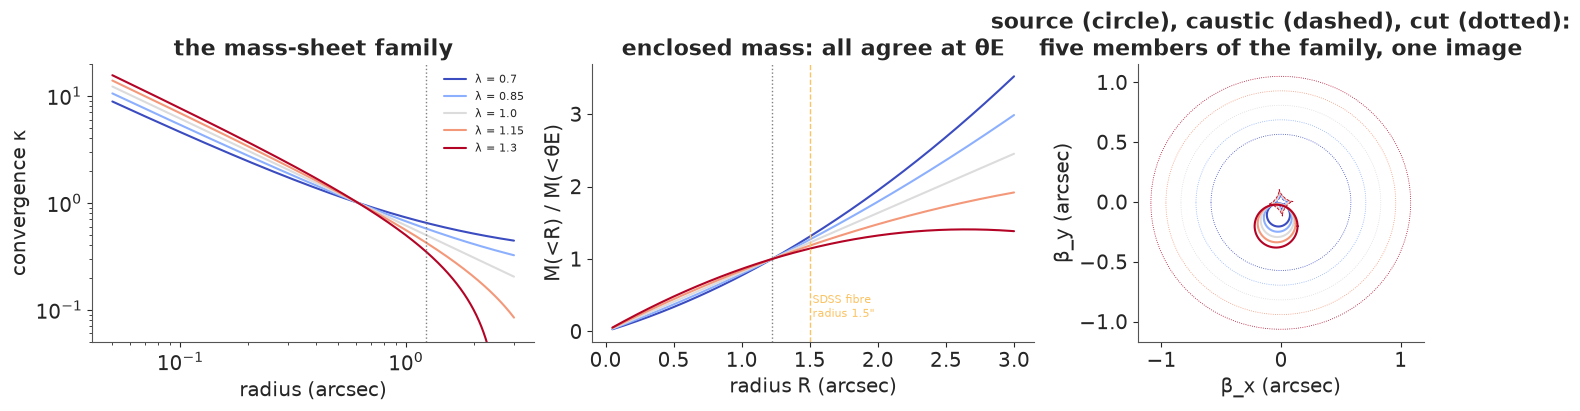

M(<1.5") relative to lambda = 1: {0.7: np.float64(1.068), 0.85: np.float64(1.034), 1.0: np.float64(1.0), 1.15: np.float64(0.966), 1.3: np.float64(0.932)}


In [24]:
te_m = TH_MEAN[10]
Rs = np.linspace(0.05, 3.0, 300)
lams = [0.7, 0.85, 1.0, 1.15, 1.3]
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for lam, col in zip(lams, plt.cm.coolwarm(np.linspace(0, 1, len(lams)))):
    kap = lam * te_m / (2 * Rs) + (1 - lam)                     # circularised SIE plus sheet
    axs[0].loglog(Rs, kap, color=col, label=f"λ = {lam}")
    m_enc = lam * te_m * Rs + (1 - lam) * Rs**2                  # M(<R) / (pi Sigma_cr), arcsec^2
    axs[1].plot(Rs, m_enc / (te_m**2), color=col)
for ax in axs[:2]:
    ax.axvline(te_m, color="0.5", ls=":", lw=1)
axs[0].set(xlabel="radius (arcsec)", ylabel="convergence κ", title="the mass-sheet family", ylim=(0.05, 20))
axs[0].legend(fontsize=8)
axs[1].axvline(1.5, color="C2", ls="--", lw=1)
axs[1].text(1.52, 0.2, "SDSS fibre\nradius 1.5\"", color="C2", fontsize=8)
axs[1].set(xlabel="radius R (arcsec)", ylabel="M(<R) / M(<θE)", title="enclosed mass: all agree at θE")
t = np.linspace(0, 2 * np.pi, 200)
for lam, col in zip(lams, plt.cm.coolwarm(np.linspace(0, 1, len(lams)))):
    axs[2].plot(lam * (TH_MEAN[21] + TH_MEAN[17] * np.cos(t)), lam * (TH_MEAN[22] + TH_MEAN[17] * np.sin(t)),
                color=col)
    crit, caus, cut = critical_and_caustics(TH_MEAN[MASS])
    for cl in caus:
        axs[2].plot(lam * cl[:, 0], lam * cl[:, 1], color=col, lw=0.6, ls="--")
    axs[2].plot(lam * cut[:, 0], lam * cut[:, 1], color=col, lw=0.6, ls=":")
axs[2].set(aspect="equal", xlabel="β_x (arcsec)", ylabel="β_y (arcsec)",
           title="source (circle), caustic (dashed), cut (dotted):\nfive members of the family, one image")
plt.show()
m15 = {lam: lam * te_m * 1.5 + (1 - lam) * 1.5**2 for lam in lams}
print("M(<1.5\") relative to lambda = 1:", {lam: round(m15[lam] / m15[1.0], 3) for lam in lams})

At the radius of the SDSS spectroscopic fibre (1.5", just outside the ring), $\lambda$ between 0.7 and
1.3 changes the enclosed mass by only a few per cent - because the fibre radius is close to
$\theta_E$, where all members agree. A velocity dispersion measured in that fibre therefore constrains
$\lambda$ only weakly unless it is very precise and the dynamical model (the stars' orbits, the light
profile) is trusted. That is exactly what joint lensing-and-dynamics studies do: for this lens,
Koopmans et al. (2006) combined the SLACS image with the stellar velocity dispersion in a spherical
Jeans model and found a total density slope $\gamma' = 2.21 \pm 0.09$ ($\rho \propto r^{-\gamma'}$;
isothermal is 2) - an assumption about the family, turned into a measurement by a second kind of data.
Other ways to break the degeneracy: **spatially resolved kinematics** (a lever arm well away from
$\theta_E$), **two sources at different redshifts** behind the same lens (the sheet cannot rescale
both source planes consistently), a **standard candle** being lensed (a type Ia supernova's known
brightness fixes the magnification), and for time-delay cosmography, an independent estimate of the
mass along the line of sight.

## F. How much mass is in the ring?

The Einstein radius is an angle; a mass needs distances. In a flat ΛCDM universe (here
$H_0 = 70$ km/s/Mpc, $\Omega_m = 0.3$, the cosmology the SLACS papers used), the comoving distance
is $\chi(z) = \frac{c}{H_0}\int_0^z \frac{dz'}{\sqrt{\Omega_m(1+z')^3 + 1 - \Omega_m}}$ (the integral of
E08), and the angular-diameter distances are $D_l = \chi_l/(1+z_l)$, $D_s = \chi_s/(1+z_s)$,
$D_{ls} = (\chi_s - \chi_l)/(1+z_s)$. The mass inside the Einstein radius is

$$M_E = \pi\,(D_l\theta_E)^2\,\Sigma_\text{cr} = \frac{c^2}{4G}\frac{D_l D_s}{D_{ls}}\,\theta_E^2,$$

and the velocity dispersion of the isothermal model that produces it is
$\sigma_\text{SIE} = c\sqrt{\frac{\theta_E}{4\pi}\frac{D_s}{D_{ls}}}$.

In [25]:
C_KM, G_SI, MPC, MSUN = 299792.458, 6.674e-11, 3.0857e22, 1.989e30
Z_L, Z_S, H0, OM = 0.2076, 0.5241, 70.0, 0.3


def chi(z):
    return C_KM / H0 * integrate.quad(lambda x: 1 / np.sqrt(OM * (1 + x) ** 3 + 1 - OM), 0, z)[0]


D_L, D_S, D_LS = chi(Z_L) / (1 + Z_L), chi(Z_S) / (1 + Z_S), (chi(Z_S) - chi(Z_L)) / (1 + Z_S)
ARCSEC = np.pi / 180 / 3600
print(f"D_l = {D_L:.0f} Mpc, D_s = {D_S:.0f} Mpc, D_ls = {D_LS:.0f} Mpc; 1\" = {D_L * 1e3 * ARCSEC:.2f} kpc at the lens, "
      f"{D_S * 1e3 * ARCSEC:.2f} kpc at the source")


def einstein_mass(te):                                    # solar masses
    return (C_KM * 1e3) ** 2 / (4 * G_SI) * D_L * D_S / D_LS * MPC * (te * ARCSEC) ** 2 / MSUN


def sigma_sie(te):                                        # km/s
    return C_KM * np.sqrt(te * ARCSEC / (4 * np.pi) * D_S / D_LS)


te_draws = TH_ALL[:, 10]
ME = einstein_mass(te_draws)
rows = [("this notebook, Sérsic source (NUTS)", te_draws.mean(), te_draws.std()),
        ("this notebook, pixelated source (Laplace)", MASS_PIX[0], sd_pix[0]),
        ("Bolton et al. 2008 (SLACS V), SIE", 1.23, 0.02 * 1.23),
        ("Koopmans et al. 2006 (SLACS III), SIE", 1.21, np.nan)]
res = pd.DataFrame(rows, columns=["model", "θE (arcsec)", "sd"])
res["R_E (kpc)"] = res["θE (arcsec)"] * D_L * 1e3 * ARCSEC
res["M_E (1e11 Msun)"] = einstein_mass(res["θE (arcsec)"]) / 1e11
res["σ_SIE (km/s)"] = sigma_sie(res["θE (arcsec)"])
print(res.round(4).to_string(index=False))
e_abs = np.hypot(TH_ALL[:, 11], TH_ALL[:, 12])
q_m = (1 - e_abs) / (1 + e_abs)
wrap = lambda a: (a + 90) % 180 - 90                         # position angles in (-90, 90]
pa_m = wrap(np.degrees(0.5 * np.arctan2(TH_ALL[:, 12], TH_ALL[:, 11])) - 90 - NORTH)   # E of N
g_abs = np.hypot(TH_ALL[:, 15], TH_ALL[:, 16])
pa_g = wrap(np.degrees(0.5 * np.arctan2(TH_ALL[:, 16], TH_ALL[:, 15])) - 90 - NORTH)
e_l = np.hypot(TH_ALL[:, 6], TH_ALL[:, 7])
pa_l = wrap(np.degrees(0.5 * np.arctan2(TH_ALL[:, 7], TH_ALL[:, 6])) - 90 - NORTH)
print(f"mass axis ratio q = {q_m.mean():.3f} ± {q_m.std():.3f}, major axis PA {pa_m.mean():.1f} ± {pa_m.std():.1f} deg E of N; "
      f"external shear {g_abs.mean():.3f} ± {g_abs.std():.3f} at PA {pa_g.mean():.0f} ± {pa_g.std():.0f} deg")
print(f"inner light component: q = {((1 - e_l) / (1 + e_l)).mean():.2f}, PA {pa_l.mean():.1f} deg")
# which way does the shear act? compare the potentials at radius theta_E along the mass's major and minor axes
te_, me1, me2, _, _, g1_, g2_ = TH_MEAN[MASS]
phi_ = 0.5 * np.arctan2(me2, me1)
for lab, ang in [("major", phi_), ("minor", phi_ + np.pi / 2)]:
    ux, uy = te_ * np.cos(ang), te_ * np.sin(ang)
    a1, a2 = sie_deflection(ux, uy, te_, me1, me2, 0.0, 0.0)
    psi_sie = float(a1 * ux + a2 * uy)                     # isothermal: psi(r) = r * d(psi)/dr
    psi_shear = 0.5 * (g1_ * (ux**2 - uy**2) + 2 * g2_ * ux * uy)
    print(f"potential along the {lab} axis at theta_E: SIE {psi_sie:.4f}, shear {psi_shear:+.4f}")
print("published SIE (no shear): Bolton+08 q = 0.91, PA 10.5 deg; Koopmans+06 q = 0.92, PA 18.7 deg; "
      "light (de Vaucouleurs, Bolton+08): q = 0.85, PA 6.9 deg")
print(f"posterior M_E: {np.mean(ME) / 1e11:.4f} ± {np.std(ME) / 1e11:.4f} x 1e11 Msun (statistical only)")
print("published: Koopmans et al. 2006 list R_E = 4.11 kpc, M_E = 2.22e11 Msun, sigma_SIE = 271 km/s; "
      "SDSS stellar velocity dispersion 290 ± 15 km/s (Bolton et al. 2008)")

D_l = 701 Mpc, D_s = 1291 Mpc, D_ls = 735 Mpc; 1" = 3.40 kpc at the lens, 6.26 kpc at the source
                                    model  θE (arcsec)     sd  R_E (kpc)  M_E (1e11 Msun)  σ_SIE (km/s)
      this notebook, Sérsic source (NUTS)       1.2231 0.0012     4.1548           2.2581      272.8099
this notebook, pixelated source (Laplace)       1.2253 0.0012     4.1625           2.2665      273.0634
        Bolton et al. 2008 (SLACS V), SIE       1.2300 0.0246     4.1784           2.2838      273.5833
    Koopmans et al. 2006 (SLACS III), SIE       1.2100    NaN     4.1104           2.2102      271.3500
mass axis ratio q = 0.839 ± 0.007, major axis PA 5.1 ± 1.3 deg E of N; external shear 0.026 ± 0.002 at PA -2 ± 3 deg
inner light component: q = 0.80, PA 2.6 deg


potential along the major axis at theta_E: SIE 1.4488, shear +0.0189
potential along the minor axis at theta_E: SIE 1.5360, shear -0.0189
published SIE (no shear): Bolton+08 q = 0.91, PA 10.5 deg; Koopmans+06 q = 0.92, PA 18.7 deg; light (de Vaucouleurs, Bolton+08): q = 0.85, PA 6.9 deg
posterior M_E: 2.2581 ± 0.0044 x 1e11 Msun (statistical only)
published: Koopmans et al. 2006 list R_E = 4.11 kpc, M_E = 2.22e11 Msun, sigma_SIE = 271 km/s; SDSS stellar velocity dispersion 290 ± 15 km/s (Bolton et al. 2008)


The Einstein radius, 1.223", is 4.15 kpc at the lens, and the mass inside it is
$2.258 \pm 0.004 \times 10^{11}$ solar masses - statistical uncertainty only. The published SIE
models agree within their stated precision: Bolton et al. (2008) found 1.23" (with a 2% empirical
error, the band in the histogram below) and Koopmans et al. (2006) 1.21", which they give as
$2.22\times 10^{11}\,M_\odot$ inside 4.11 kpc. Our $\theta_E$ lies between the two, and the two
published values differ from each other by 0.02" - seventeen of our posterior sds. The honest error
bar on the mass is set by modelling choices (source model, lens light, PSF, the SIE itself), about
1-2%, not by the 0.2% statistical width. The mass inside the Einstein radius is the robust number
here: as Part E showed, it is untouched even by the mass-sheet degeneracy.

The isothermal model's velocity dispersion, 273 km/s, can be compared with the stars' velocity
dispersion measured in the SDSS spectrum, 290 ± 15 km/s: the ratio is 1.06 ± 0.06, consistent with
an isothermal lens within the measurement error. Koopmans et al.'s joint lensing and Jeans analysis
(with their own aperture-corrected dispersion, 275 ± 12 km/s) gave a total density slope
$\gamma' = 2.21 \pm 0.09$, slightly steeper than isothermal (Part E).

The shape differs from the published shear-free SIEs (axis ratio 0.84 at PA 5 degrees against
0.91-0.92 at PA 10-19 degrees). Our model also has an external shear, and its axis (PA about -2
degrees) nearly coincides with the mass's major axis - in this orientation the shear's potential
*opposes* the ellipsoid's quadrupole (printed above: along the major axis the SIE's potential is
lower, the shear's higher), so the mass must be flatter to produce the same net distortion. Imaging
alone separates internal ellipticity from external shear only weakly, which is why the published
shapes depend on whether shear was included. The mass's major axis is within a few degrees of the
light's (PA 3-7 degrees).

Finally, the lens's critical curves and caustics, drawn once per posterior draw: in the image plane
over the lens-subtracted data, and in the source plane over the reconstructed galaxy.

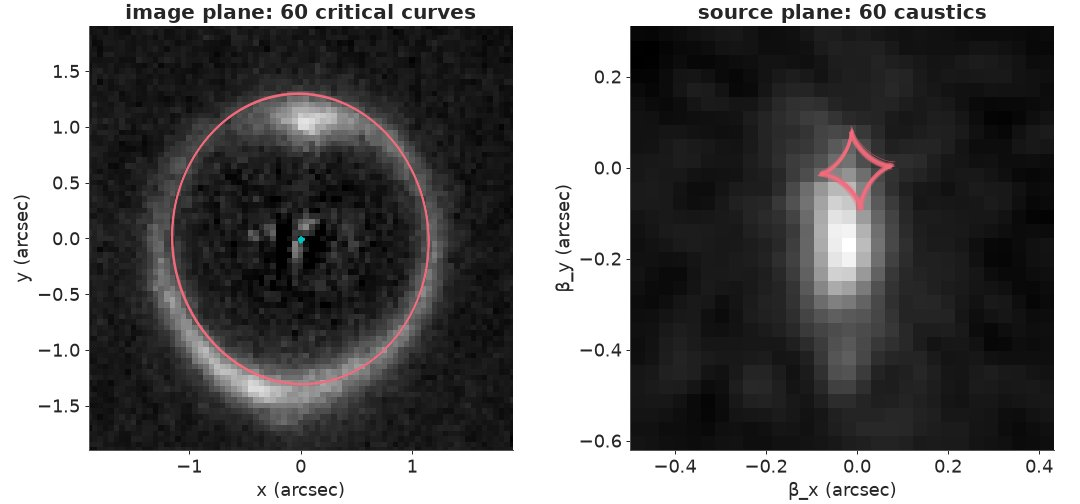

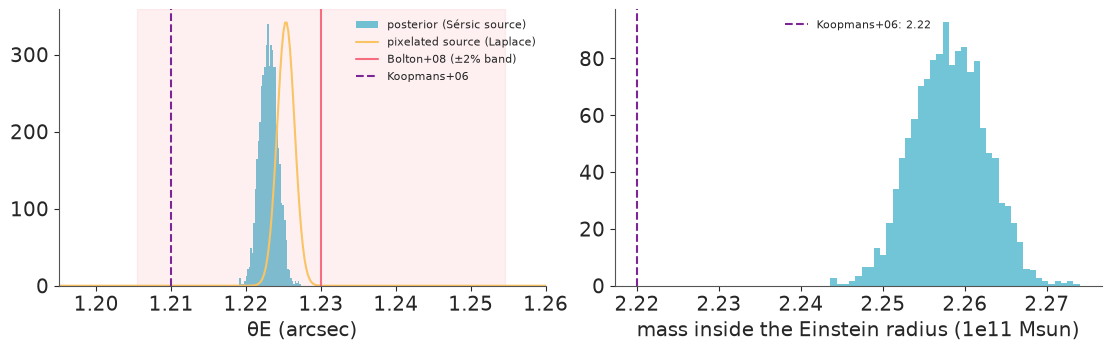

total run time 217 s


In [26]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5.6))
axs[0].imshow(sci - light_mean, origin="lower", cmap="gray", vmin=-0.03, vmax=0.3, extent=EXT)
for crit in crit_draws:
    for cl in crit:
        axs[0].plot(cl[:, 0], cl[:, 1], color="C1", lw=0.4, alpha=0.4)
axs[0].plot(TH_60[:, 13], TH_60[:, 14], "+", color="c", ms=4)
axs[0].set(xlim=(-1.9, 1.9), ylim=(-1.9, 1.9), xlabel="x (arcsec)", ylabel="y (arcsec)",
           title="image plane: 60 critical curves")
axs[1].imshow(mean_s, origin="lower", cmap="gray", extent=EXT_S)
for caus, cut in caustic_draws:
    for cl in caus:
        axs[1].plot(cl[:, 0], cl[:, 1], color="C1", lw=0.4, alpha=0.4)
axs[1].set(xlim=EXT_S[:2], ylim=EXT_S[2:], xlabel="β_x (arcsec)", ylabel="β_y (arcsec)",
           title="source plane: 60 caustics")
show_jpeg(fig)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
axs[0].hist(te_draws, bins=40, color="C0", alpha=0.7, density=True, label="posterior (Sérsic source)")
xx_ = np.linspace(1.195, 1.26, 300)
axs[0].plot(xx_, np.exp(-0.5 * ((xx_ - MASS_PIX[0]) / sd_pix[0]) ** 2) / (sd_pix[0] * np.sqrt(2 * np.pi)),
            color="C2", label="pixelated source (Laplace)")
axs[0].axvline(1.23, color="C1", label="Bolton+08 (±2% band)")
axs[0].axvspan(1.23 * 0.98, 1.23 * 1.02, color="C1", alpha=0.1)
axs[0].axvline(1.21, color="C3", ls="--", label="Koopmans+06")
axs[0].set(xlabel="θE (arcsec)", xlim=(1.195, 1.26))
axs[0].legend(fontsize=8)
axs[1].hist(ME / 1e11, bins=40, color="C0", alpha=0.7, density=True)
axs[1].axvline(2.22, color="C3", ls="--", label="Koopmans+06: 2.22")
axs[1].set(xlabel="mass inside the Einstein radius (1e11 Msun)")
axs[1].legend(fontsize=8)
plt.show()
jax.clear_caches()
print(f"total run time {time.time() - T_START:.0f} s")

The 60 critical curves (image plane) and caustics (source plane) lie on top of one another: with the
lens model fixed as an SIE plus shear, the image pins down the geometry of the lens to a few
milli-arcseconds. The spaghetti shows how *little* the posterior allows - and, like every posterior
sd in this notebook, says nothing about how the picture would change with a different mass model.

## Summary

* **A likelihood for every pixel.** 6,561 pixels of an HST image, with a noise map from the sky and
  the photon counts, the telescope's PSF measured from nine stars, and the lens galaxy's light fitted
  together with the ring. Four brightness amplitudes were integrated out exactly, leaving 23 nonlinear
  parameters and a noise scale for NUTS: with nutpie's low-rank mass matrix, 4 chains of 600 draws in
  about 2.5 minutes, $\hat R \le 1.01$.
* **Correlated noise matters for the error bars, not the fit.** Drizzling correlates neighbouring
  pixels (sum of correlations 2.1); whitening in Fourier space fixes the likelihood, and ignoring it
  shrank every posterior sd by a factor of 1.4 with no visible sign in the residuals.
* **Lens posteriors have wrong modes.** All six optimisations from random prior draws ended 780 to
  7,500 log-likelihood units below the best fit; a staged start (lens light, then the ring's radius,
  then a few source positions) found it four times out of five.
* **Failures teach what the data constrain.** Without the PSF the fit is 2,000 units worse and the
  source comes out 3.5 times too large, while $\theta_E$ moves by 1%.
* **The Einstein radius is the robust output.** $\theta_E = 1.2231 \pm 0.0012"$ with a Sérsic source,
  1.2253 ± 0.0012" with a pixelated source whose 900 pixels were integrated out and whose
  regularisation (curvature, not gradient or none) was chosen by the Bayesian evidence. The difference
  between source models is about twice the statistical sd: model choices set the real error, as the
  SLACS papers' 2% empirical error acknowledges. Both lie between the published 1.21" and 1.23".
* **Mass:** $M(<\theta_E) = 2.26 \times 10^{11}\,M_\odot$ inside 4.15 kpc for flat ΛCDM with
  $H_0 = 70$; the isothermal velocity dispersion, 273 km/s, is consistent with the SDSS stellar value.
* **The mass-sheet degeneracy is exact.** Scaling the lens and adding a uniform sheet reproduced the
  image to a few parts in $10^8$ while changing the profile slope, the masses at other radii, the
  source's size and any time delay. It leaves the mass inside the Einstein radius alone. Only other
  data - kinematics away from $\theta_E$, a second source plane, a lensed standard candle - can break it.
* **Uncertainty displays** for an inverse problem: residual maps in units of σ, sector-averaged
  residuals along the ring, the unlensed galaxy's mean, sd and signal-to-noise maps, 60 caustics drawn
  over it, and an animation of posterior draws - which shows that the galaxy's shape is secure and its
  faint structure is not.

## Try it yourself

1. **Measure the slope.** Replace the SIE by an elliptical power law, $\kappa \propto R^{1-\gamma'}$
   (deflection via the hypergeometric series of Tessore & Metcalf 2015, or numerically for a round
   lens). How well does the image alone constrain $\gamma'$, and how does its posterior correlate
   with the source size? Relate what you find to the mass-sheet degeneracy of Part E; then add the
   SDSS velocity dispersion (290 ± 15 km/s) through a spherical Jeans model and compare with Koopmans
   et al.'s $\gamma' = 2.21 \pm 0.09$.
2. **Another lens.** `tools/build_e80_lens.py` takes a MAST drizzled image; change the coordinates
   and product name to another SLACS lens - for instance SDSS J0946+1006, the "Jackpot", with two
   rings from two sources at different redshifts - and rerun Parts A-D. What changes in the modes
   the optimiser finds? For the Jackpot, why do two source planes break the mass-sheet degeneracy?
3. **Sample the lens with the source marginalised.** Wrap the evidence of Part D with `wrap_jax` and
   sample the seven mass parameters and $\log\lambda$ with NUTS (a coarser source grid, 20 x 20, makes
   each gradient cheaper). Does the posterior of $\theta_E$ agree with the Laplace approximation,
   and how much wider is the combined uncertainty if you pool the Sérsic and pixelated source models?